# Meteo

REF:
- https://dominicroye.github.io/blog/spain-temperature-normals-openmeteo/?utm_campaign=Data_Elixir&utm_source=Data_Elixir_579&_bhlid=b8c9c02693572f9fca51761ec962a24d9cac66dd

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import seaborn as sns

import matplotlib.dates as mdates


In [ ]:
import sqlite3

In [ ]:
conn = sqlite3.connect('/content/.cache.sqlite')

In [ ]:
sql_query = """SELECT name FROM sqlite_master
WHERE type='table';"""
cursor = conn.cursor()
cursor.execute(sql_query)
result = cursor.fetchone()
print(result)
conn.commit()
cursor.close()

None


In [ ]:
torch.cuda.is_available()

False

REF:
-  https://data.gov.gr/dataset/cee4f7c1-68b3-4014-b7c7-926584b7bfe5/resource/ca01bd85-1d39-47fc-ae77-4692b7d5b87e

In [ ]:
!curl -L -o stations_data.zip https://data.gov.gr/dataset/cee4f7c1-68b3-4014-b7c7-926584b7bfe5/resource/ca01bd85-1d39-47fc-ae77-4692b7d5b87e/download/stations-data-ers00i6z.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100   697  100   697    0     0    343      0  0:00:02  0:00:02 --:--:--   343
100 5422k  100 5422k    0     0  1236k      0  0:00:04  0:00:04 --:--:-- 3873k


In [ ]:
!mkdir /content/stations_data

In [ ]:
!unzip /content/stations_data.zip -d /content/stations_data

Archive:  /content/stations_data.zip
  inflating: /content/stations_data/meteo_datagov.zip  
  inflating: /content/stations_data/datapackage.json  


In [ ]:
import json
with open('/content/stations_data/datapackage.json') as f:
  data_package = json.load(f)
print(data_package)

{'description': 'Το σύνολο των δεδομένων αφορά ημερήσιες μετεωρολογικές παραμέτρους για την περίοδο 2010-2023 από 54 μετεωρολογικούς σταθμούς. Μπορείτε να δείτε οπτικοποιήσεις των δεδομένων αυτών των σταθμών στην σελίδα https://www.meteo.gr/climate/\r\nΟι παράμετροι είναι θερμοκρασία (°C), σχετική υγρασία (%), πίεση (hPa), βροχόπτωση (mm), ταχύτητα (km/h), επικρατούσα διεύθυνση ανέμου και ριπή ανέμου(km/h).\r\nΟι μετρήσεις προέρχονται από το δίκτυο των αυτόματων μετεωρολογικών σταθμών του Εθνικού Αστεροσκοπείου Αθηνών/meteo.gr.\r\nΠληροφορίες για τους σταθμούς και για τυχόν δυσλειτουργίες δίνονται στο http://meteosearch.meteo.gr/ στην σελίδα του αντίστοιχου σταθμού.\r\nΑναφορά στο δίκτυο γίνεται μέσω της επιστημονικής δημοσίευσης https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/gdj3.44', 'keywords': ['Εθνικό Αστεροσκοπείο Αθηνών', 'βροχόπτωση', 'ημερήσιες μετεωρολογικές παράμετροι', 'θερμοκρασία ημέρας', 'σχετική υγρασία'], 'name': 'stations-data', 'resources': [{'format': 'ZIP',

In [ ]:
!mkdir /content/stations_data/meteo_data

In [ ]:
!unzip /content/stations_data/meteo_datagov.zip -d /content/stations_data/meteo_data

In [ ]:
!head -n 10 /content/stations_data/meteo_data/stations_list.csv

stations,latitude,longitude,altitude
aghiosnikolaos,35.187909,25.715552,30.0
alexandroupolis,40.876310,25.858280,69.0
amfiklia,38.611420,22.640530,245.0
argos,37.628115,22.713401,38.0
arta,39.172784,20.999435,50.0
athens,37.978408,23.715448,50.0
chania,35.533365,24.068349,137.0
dion,40.223638,22.470709,50.0
drama,41.117828,24.143734,83.0


In [ ]:
!head -n 10  /content/stations_data/meteo_data/stations_data/thessaloniki.csv

Date,T_mean,T_max,T_min,RH_mean,RH_max,RH_min,Prs_mean,Prs_max,Prs_min,Ac_R,WS_mean,DWD,WG
2010-01-01,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-02,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-03,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-04,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-05,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-06,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-07,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-08,---,---,---,---,---,---,---,---,---,---,---,---,---
2010-01-09,---,---,---,---,---,---,---,---,---,---,---,---,---


### Dataset Exploration

In [ ]:
thessaloniki = pd.read_csv('/content/stations_data/meteo_data/stations_data/thessaloniki.csv', header = 0, index_col=None)

In [ ]:
thessaloniki.columns = pd.Index([colname.replace(" ", "_").lower() for colname in thessaloniki.columns])

In [ ]:
thessaloniki.columns

In [ ]:
thessaloniki.t_mean.value_counts(dropna=False, normalize=False)

In [ ]:
def mapToNan(col: pd.Series) -> pd.Series:
  return col.replace({'---':np.nan})

In [ ]:
thessaloniki_clean = thessaloniki.apply(mapToNan, axis = 1)
thessaloniki_clean.info()

In [ ]:
thessaloniki_clean[thessaloniki_clean['ac_r'].isna()].index

In [ ]:
np.all(thessaloniki[thessaloniki['ac_r'] == '---'].index == thessaloniki_clean[thessaloniki_clean['ac_r'].isna()].index)

In [ ]:
thessaloniki_clean.head()

In [ ]:
thessaloniki_clean.date = pd.to_datetime(thessaloniki_clean.date, format="%Y-%m-%d")

In [ ]:
thessaloniki_clean['date'].dt.year.unique()

In [ ]:
thessaloniki_clean.loc[:, "city"] = "thessaloniki"

In [ ]:
thessaloniki_clean.tail()

In [ ]:
numeric_cols = ["t_mean",	"t_max",	"t_min",	"rh_mean",	"rh_max",	"rh_min",	"prs_mean",	"prs_max",	"prs_min",	"ac_r",	"ws_mean", "wg"]
categorical_cols =["dwd", "city"]
date_cols = ["date"]

In [ ]:
def mapToType(col: pd.Series, numeric_cols = numeric_cols, categorical_cols=categorical_cols)->pd.Series:
  if col.name in numeric_cols:
    return col.astype(np.float32)
  elif col.name in categorical_cols:
    return col.astype('category')
  elif col.name in date_cols:
    return pd.to_datetime(col, format="%Y-%m-%d")
  else:
    return col

In [ ]:
thessaloniki_clean = thessaloniki_clean.apply(mapToType)

In [ ]:
thessaloniki_clean.info()

In [ ]:
thessaloniki_clean.dwd = thessaloniki_clean.dwd.astype('category')

In [ ]:
thessaloniki_clean.info()

In [ ]:
thessaloniki_clean[numeric_cols]

In [ ]:
all_null_rows = thessaloniki_clean[thessaloniki_clean[numeric_cols].isna().sum(axis = 1) == len(numeric_cols)]
all_null_rows

In [ ]:
all_null_rows.loc[:, ['year']] = all_null_rows.date.dt.year
all_null_rows['year'].value_counts(dropna=False, normalize=False)

In [ ]:
thessaloniki_clean.loc[:, ['year']] = thessaloniki_clean.date.dt.year

In [ ]:
thessaloniki_clean.year.value_counts(dropna=False, normalize = False)

### Load All

In [ ]:
stations = pd.read_csv('/content/stations_data/meteo_data/stations_list.csv', header = 0, index_col=None)
station_names = stations['stations'].unique()
station_names

array(['aghiosnikolaos', 'alexandroupolis', 'amfiklia', 'argos', 'arta',
       'athens', 'chania', 'dion', 'drama', 'florina', 'grevena',
       'heraclion', 'igoumenitsa', 'ioannina', 'ithaki', 'kea', 'kerkyra',
       'kilkis', 'kyparissia', 'larissa', 'lavrio', 'lefkada', 'lemnos',
       'livadeia', 'megalopoli', 'petrokefali', 'mornos1', 'naousa',
       'nemea', 'nevrokopi', 'notiopedio', 'orestiada', 'paros', 'patra',
       'pirgos', 'polygyros', 'ptolemaida', 'rethymno', 'samos',
       'samothraki', 'skopelos', 'sparti', 'tanagra', 'thessaloniki',
       'tinos', 'trikala', 'tripoli', 'vatopedi', 'veroia', 'volos',
       'xanthi', 'lindos', 'gavalou', 'karpenisitown'], dtype=object)

In [ ]:
def load_data() -> pd.DataFrame:
  stations=pd.read_csv('/content/stations_data/meteo_data/stations_list.csv', header=0, index_col=None)
  station_names=stations['stations'].unique()
  dfs = []
  for name in station_names:
    station_df = pd.read_csv(f'/content/stations_data/meteo_data/stations_data/{name}.csv', header = 0, index_col=None)
    # add identifier for the source
    station_df.loc[:, 'station'] = name
    # helper for column names
    station_df.columns = pd.Index([colname.replace(" ", "_").lower() for colname in station_df.columns])
    dfs.append(station_df)

  # return new DataFrame with index = (0,...,n)
  return pd.concat(dfs, axis = 0, ignore_index = True)

In [ ]:
df = load_data()
df.head()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
0,2010-01-01,21.7,27.4,17.4,43.6,78,20,1008.3,1010.4,1005.4,0.0,15.6,SE,72.4,aghiosnikolaos
1,2010-01-02,17.5,20.8,14.1,58.6,82,37,1009.4,1012.0,1007.5,0.0,7.7,W,48.3,aghiosnikolaos
2,2010-01-03,16.5,19.1,14.3,54.4,68,38,1012.8,1015.0,1011.3,0.0,8.5,WNW,45.1,aghiosnikolaos
3,2010-01-04,14.0,15.9,11.9,62.5,70,53,1018.9,1021.5,1014.6,0.0,13.9,N,57.9,aghiosnikolaos
4,2010-01-05,14.4,16.8,11.7,70.2,79,63,1019.2,1021.5,1016.4,0.0,13.1,S,62.8,aghiosnikolaos


In [ ]:
df.shape, df.index.nunique()

((276102, 15), 276102)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276102 entries, 0 to 276101
Data columns (total 15 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   date      276102 non-null  object
 1   t_mean    276102 non-null  object
 2   t_max     276102 non-null  object
 3   t_min     276102 non-null  object
 4   rh_mean   276102 non-null  object
 5   rh_max    276102 non-null  object
 6   rh_min    276102 non-null  object
 7   prs_mean  276102 non-null  object
 8   prs_max   276102 non-null  object
 9   prs_min   276102 non-null  object
 10  ac_r      276102 non-null  object
 11  ws_mean   276102 non-null  object
 12  dwd       276102 non-null  object
 13  wg        276102 non-null  object
 14  station   276102 non-null  object
dtypes: object(15)
memory usage: 31.6+ MB


In [ ]:
df[df.station == 'thessaloniki']

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station
219859,2010-01-01,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219860,2010-01-02,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219861,2010-01-03,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219862,2010-01-04,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
219863,2010-01-05,---,---,---,---,---,---,---,---,---,---,---,---,---,thessaloniki
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
224967,2023-12-27,11.4,16.6,7.9,81.2,94,67,1022.7,1027.0,1019.4,0.0,6.8,W,27.4,thessaloniki
224968,2023-12-28,10.0,14.6,6.7,85.2,90,75,1026.4,1028.9,1023.5,0.0,1.8,SSW,8.0,thessaloniki
224969,2023-12-29,9.0,12.9,6.3,90.4,95,78,1021.3,1023.5,1019.7,0.4,2.0,E,12.9,thessaloniki
224970,2023-12-30,8.4,12.4,5.6,90.3,96,76,1019.8,1021.4,1018.7,0.2,2.0,ESE,11.3,thessaloniki


In [ ]:
def encode_data(df: pd.DataFrame) -> pd.DataFrame:
    # Define column groups
    numeric_cols = ["t_mean", "t_max", "t_min", "rh_mean", "rh_max", "rh_min", "prs_mean", "prs_max", "prs_min", "ac_r", "ws_mean", "wg"]
    categorical_cols = ["dwd", "station"]

    # replace '---' with NaN for the entire DataFrame at once
    df = df.replace('---', np.nan)

    # convert numeric columns and raise error for value that can't be coerced
    for col in numeric_cols:
      if col in df:
        df[col] = pd.to_numeric(df[col], errors='raise').astype(np.float32)

    # convert categorical columns
    for col in categorical_cols:
      if col in df:
        df[col] = df[col].astype('category')

    # convert of date
    #if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], format="%Y-%m-%d")
    # also add the year as helper
    df.loc[:, ['year']] = df.date.dt.year

    # return sorted by station, date
    return df.sort_values(by=['station', 'date'])

In [ ]:
data = encode_data(df.copy())
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 276102 entries, 0 to 260762
Data columns (total 16 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   date      276102 non-null  datetime64[ns]
 1   t_mean    265261 non-null  float32       
 2   t_max     265261 non-null  float32       
 3   t_min     265261 non-null  float32       
 4   rh_mean   265532 non-null  float32       
 5   rh_max    265532 non-null  float32       
 6   rh_min    265532 non-null  float32       
 7   prs_mean  265097 non-null  float32       
 8   prs_max   265097 non-null  float32       
 9   prs_min   265097 non-null  float32       
 10  ac_r      266023 non-null  float32       
 11  ws_mean   266242 non-null  float32       
 12  dwd       264868 non-null  category      
 13  wg        266245 non-null  float32       
 14  station   276102 non-null  category      
 15  year      276102 non-null  int32         
dtypes: category(2), datetime64[ns](1), float32(

In [ ]:
data.tail()

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station,year
260758,2023-12-27,10.4,18.200001,4.9,63.299999,73.0,44.0,1022.700012,1027.400024,1019.000000,0.2,1.4,NNW,11.300000,xanthi,2023
260759,2023-12-28,9.1,15.900000,4.0,63.200001,72.0,49.0,1026.800049,1029.199951,1023.500000,0.2,1.7,SE,16.100000,xanthi,2023
260760,2023-12-29,8.4,15.300000,2.9,66.599998,72.0,55.0,1021.700012,1023.599976,1019.900024,0.2,1.9,NW,16.100000,xanthi,2023
260761,2023-12-30,8.8,15.700000,3.6,65.699997,73.0,54.0,1019.900024,1021.200012,1018.599976,0.2,2.1,WNW,17.700001,xanthi,2023
260762,2023-12-31,9.7,15.300000,4.5,66.199997,71.0,56.0,1019.799988,1021.700012,1018.599976,0.2,1.3,N,9.700000,xanthi,2023


In [ ]:
grouped = data.groupby(['year','station'], observed=False).agg({'station': 'count'})
grouped.columns = ["count"]
grouped.reset_index(level=1)

,station,count
year,,
2010,aghiosnikolaos,365
2010,alexandroupolis,365
2010,amfiklia,365
2010,argos,365
2010,arta,365
...,...,...
2023,tripoli,365
2023,vatopedi,365
2023,veroia,365


In [ ]:
grouped[grouped['count']  < 365]

,,count
year,station,


In [ ]:
years_by_station = data.groupby('station', observed = False).agg({'year': 'unique'})
years_by_station.year.transform(len)

,year
station,
aghiosnikolaos,14
alexandroupolis,14
amfiklia,14
argos,14
arta,14
athens,14
chania,14
dion,14
drama,14


In [ ]:
years_by_station.year.map(lambda x: ','.join([str(i) for i in x])).unique()

array(['2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023'],
      dtype=object)

## Clean

In [ ]:
def get_all_null_rows(df: pd.DataFrame, subset_x: list[str] = ['date','year','station','dwd']) -> pd.DataFrame:
  d = df.drop(columns=subset_x)
  return d[d.isna().all(axis = 1)] # d[d.isna().sum(axis=1)==len(d.columns)]

In [ ]:
all_null_rows = get_all_null_rows(data)
all_null_rows

,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,wg
327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
328,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
329,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
330,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
331,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
259055,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259057,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
259058,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
all_null_rows.index

Index([   327,    328,    329,    330,    331,    332,    394,   2631,   3142,
         3143,
       ...
       253856, 253857, 253858, 259053, 259054, 259055, 259056, 259057, 259058,
       259059],
      dtype='int64', length=9796)

In [ ]:
def get_all_null_rows_with_identifiers(df: pd.DataFrame) -> pd.DataFrame:
  all_null_rows = get_all_null_rows(data)
  all_null_rows_with_identifiers = pd.merge(all_null_rows, df[['station','year']], left_index=True, right_index=True).groupby(['station','year'], observed = False).station.count()
  all_null_rows_with_identifiers.name = 'counts'
  # data_long = all_null_rows_with_identifiers.reset_index(name='count').sort_values(by=['count'], ascending=[False]).head(20)
  # data_long
  all_null_rows_with_identifiers = all_null_rows_with_identifiers.reset_index(level=0)
  return all_null_rows_with_identifiers.pivot(columns='station', values='counts')

all_null_rows_wide = get_all_null_rows_with_identifiers(data)
all_null_rows_wide

station,aghiosnikolaos,alexandroupolis,amfiklia,argos,arta,athens,chania,dion,drama,florina,...,sparti,tanagra,thessaloniki,tinos,trikala,tripoli,vatopedi,veroia,volos,xanthi
year,,,,,,,,,,,,,,,,,,,,,
2010,6,0,0,365,30,0,0,3,11,0,...,0,0,365,0,0,30,1,30,2,0
2011,1,0,0,365,0,0,0,3,0,0,...,0,0,365,2,0,0,0,0,0,0
2012,0,0,0,233,0,0,0,0,1,4,...,15,0,52,0,0,0,0,0,0,0
2013,0,0,0,0,0,0,17,0,0,0,...,0,3,0,0,0,3,0,6,0,0
2014,0,0,0,0,0,0,0,1,0,8,...,10,0,1,0,0,0,1,0,0,0
2015,0,0,0,0,0,0,0,4,0,0,...,0,0,0,22,0,0,0,0,0,0
2016,0,0,0,0,0,0,0,0,0,0,...,0,12,0,0,0,0,120,1,0,0
2017,1,0,13,0,0,0,0,0,0,0,...,0,0,0,6,0,0,0,0,3,0
2018,8,0,0,0,124,0,0,0,0,0,...,0,0,0,3,0,0,14,17,0,0


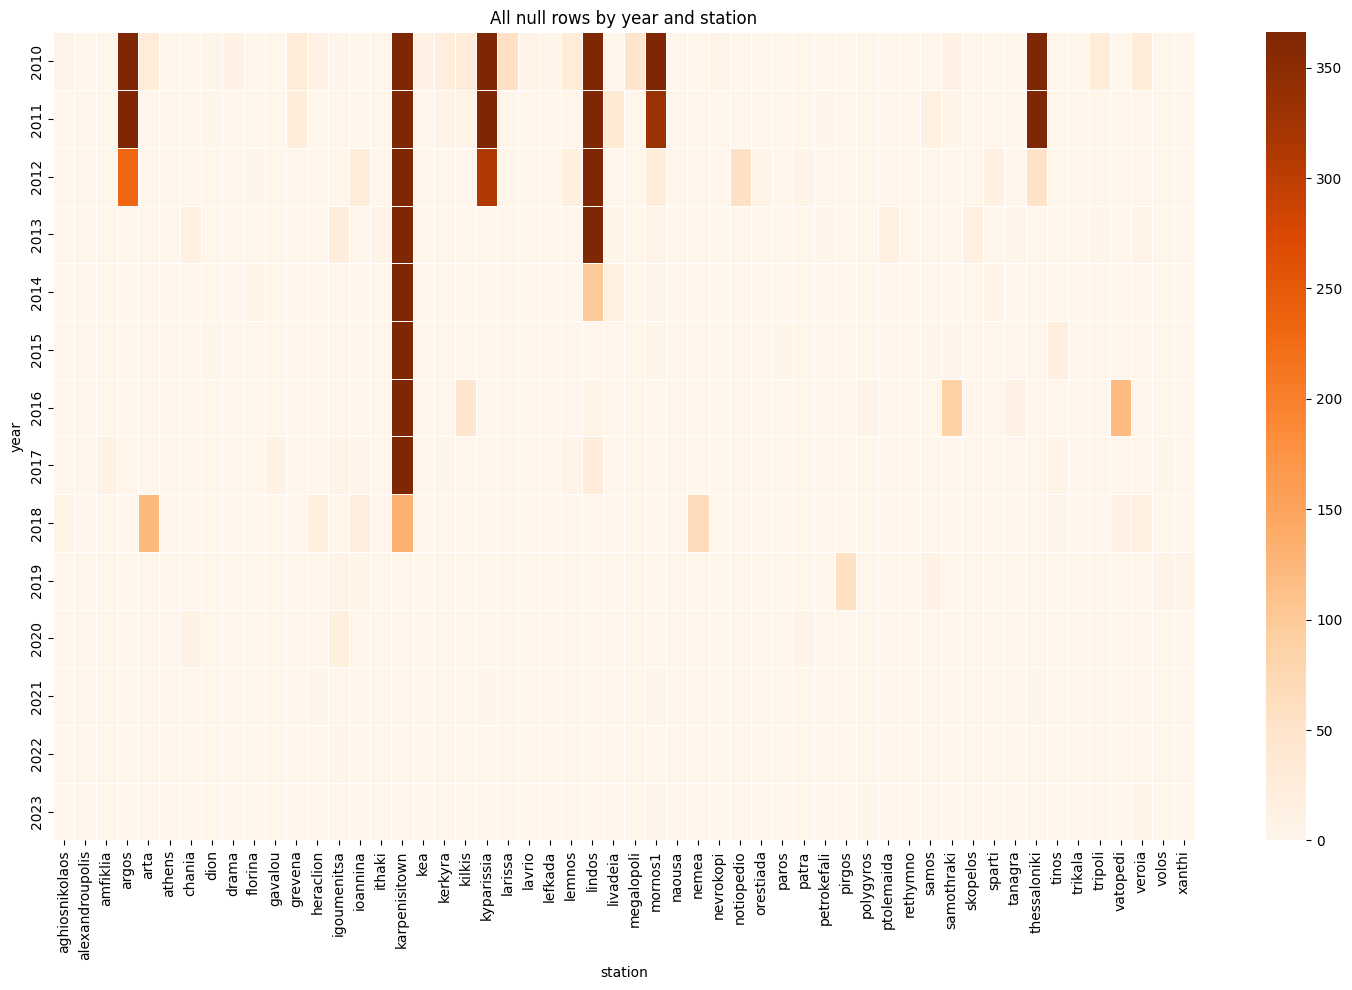

In [ ]:
plt.figure(figsize=(15,10))
plt.title('All null rows by year and station')
sns.heatmap(all_null_rows_wide, cmap="Oranges",linewidth=.5)
plt.tight_layout()
plt.show()

drop all-null rows

we can't use bfill/ffill when all the values for a year are missing. So drop all the rows that belong to a year where all the values for a station are missing

In [ ]:
all_null_filtering_condition = all_null_rows_wide.isin([365,366])
all_null_filtering_condition

station,aghiosnikolaos,alexandroupolis,amfiklia,argos,arta,athens,chania,dion,drama,florina,...,sparti,tanagra,thessaloniki,tinos,trikala,tripoli,vatopedi,veroia,volos,xanthi
year,,,,,,,,,,,,,,,,,,,,,
2010,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2011,False,False,False,True,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
2012,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2013,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2014,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2015,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2016,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2017,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2018,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
all_null_filtering_condition.stack()[all_null_filtering_condition.stack()]

year  station      
2010  argos            True
      karpenisitown    True
      kyparissia       True
      lindos           True
      mornos1          True
      thessaloniki     True
2011  argos            True
      karpenisitown    True
      kyparissia       True
      lindos           True
      thessaloniki     True
2012  karpenisitown    True
      lindos           True
2013  karpenisitown    True
      lindos           True
2014  karpenisitown    True
2015  karpenisitown    True
2016  karpenisitown    True
2017  karpenisitown    True
dtype: bool

In [ ]:
def get_year_station_pairs_with_all_null_rows(df: pd.DataFrame) -> list[tuple[int,str]]:
  """
    Return (year, station) pairs will all nu values in the rumerical columns
   """
  all_null_rows_wide = get_all_null_rows_with_identifiers(df)
  all_null_filtering_condition = all_null_rows_wide.isin([365,366])

  # Stack the wide dataframe to get a long-form Series of booleans
  # Then filter for True values and reset the index to see the pairs
  missing_years_stations = all_null_filtering_condition.stack()

  # get the multiIndex values = (year, station)
  return missing_years_stations[missing_years_stations].index.to_list()


missing_years_stations = get_year_station_pairs_with_all_null_rows(data)


print("Station-Year pairs where all rows corresponding to a specific year are null:")
for year, station in missing_years_stations:
  print(f"Year: {year}, Station: {station}")

Station-Year pairs where all rows corresponding to a specific year are null:
Year: 2010, Station: argos
Year: 2010, Station: karpenisitown
Year: 2010, Station: kyparissia
Year: 2010, Station: lindos
Year: 2010, Station: mornos1
Year: 2010, Station: thessaloniki
Year: 2011, Station: argos
Year: 2011, Station: karpenisitown
Year: 2011, Station: kyparissia
Year: 2011, Station: lindos
Year: 2011, Station: thessaloniki
Year: 2012, Station: karpenisitown
Year: 2012, Station: lindos
Year: 2013, Station: karpenisitown
Year: 2013, Station: lindos
Year: 2014, Station: karpenisitown
Year: 2015, Station: karpenisitown
Year: 2016, Station: karpenisitown
Year: 2017, Station: karpenisitown


In [ ]:
data.apply(lambda row: (row['year'], row['station']) in missing_years_stations, axis=1)

,0
0,False
1,False
2,False
3,False
4,False
...,...
260758,False
260759,False
260760,False
260761,False


In [ ]:
def handle_missing_years_stations(df: pd.DataFrame) -> pd.DataFrame:

  missing_years_stations: list[tuple[int,str]] = get_year_station_pairs_with_all_null_rows(df)

  # Create a filter for rows to exclude based on the list of (year, station) tuples
  # use apply with axis 1 (takes in each row) because we want to have access to 2 column names for each row
  mask = df.apply(lambda row: (row['year'], row['station']) in missing_years_stations, axis=1)

  print(f"Removed rows: {mask.sum()}")

  # Create the cleaned dataframe
  data_cleaned =  df[~mask].copy()

  # fill forwards and backwards for up to 3 days
  data_cleaned = data_cleaned.bfill(limit=3)
  data_cleaned = data_cleaned.ffill(limit=3)

  # drop other N/A that we don't want to fill
  data_cleaned = data_cleaned.dropna()

  return data_cleaned

data_cleaned = handle_missing_years_stations(data)


print(f"Original rows: {len(data)}")
print(f"Cleaned rows: {len(data_cleaned)}")
data_cleaned.head()

Removed rows: 6938
Original rows: 276102
Cleaned rows: 264789


,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station,year
0,2010-01-01,21.700001,27.400000,17.4,43.599998,78.0,20.0,1008.299988,1010.400024,1005.400024,0.0,15.6,SE,72.400002,aghiosnikolaos,2010
1,2010-01-02,17.500000,20.799999,14.1,58.599998,82.0,37.0,1009.400024,1012.000000,1007.500000,0.0,7.7,W,48.299999,aghiosnikolaos,2010
2,2010-01-03,16.500000,19.100000,14.3,54.400002,68.0,38.0,1012.799988,1015.000000,1011.299988,0.0,8.5,WNW,45.099998,aghiosnikolaos,2010
3,2010-01-04,14.000000,15.900000,11.9,62.500000,70.0,53.0,1018.900024,1021.500000,1014.599976,0.0,13.9,N,57.900002,aghiosnikolaos,2010
4,2010-01-05,14.400000,16.799999,11.7,70.199997,79.0,63.0,1019.200012,1021.500000,1016.400024,0.0,13.1,S,62.799999,aghiosnikolaos,2010


In [ ]:
# # fill forwards and backwards for up to 3 days
# data_cleaned = data_cleaned.bfill(limit=3)
# data_cleaned = data_cleaned.ffill(limit=3)

#data_cleaned = data_cleaned.dropna()

In [ ]:
data_cleaned.isna().sum()

,0
date,0
t_mean,0
t_max,0
t_min,0
rh_mean,0
rh_max,0
rh_min,0
prs_mean,0
prs_max,0
prs_min,0


## Utils

In [ ]:
def get_day_for_month(df: pd.DataFrame) -> dict:
  values =  df[['yd','month']].values
  month_set = {a[0]: a[1] for a in values if not a[0] % 29}
  return month_set

In [ ]:
def get_station_data(df:pd.DataFrame, station:str, reset_index=False)->pd.DataFrame:
  if reset_index:
    return df[df.station == station].reset_index(drop=True)
  return df[df.station == station]

In [ ]:
def get_best_param_index(errors: np.ndarray) -> int:
  return np.argmin(errors)

## Step 1: choosing the reference locations

In [ ]:
stations

,stations,latitude,longitude,altitude
0,aghiosnikolaos,35.187909,25.715552,30.0
1,alexandroupolis,40.876310,25.858280,69.0
2,amfiklia,38.611420,22.640530,245.0
3,argos,37.628115,22.713401,38.0
4,arta,39.172784,20.999435,50.0
5,athens,37.978408,23.715448,50.0
6,chania,35.533365,24.068349,137.0
7,dion,40.223638,22.470709,50.0
8,drama,41.117828,24.143734,83.0
9,florina,40.794947,21.420556,637.0


In [ ]:
data_cleaned.shape

(264789, 16)

Data for karpenisitown is only available after 2018 and for Lindos after 2014. Better to drop these 2 stations and continue with data from 2012 to 2023 from all other stations

In [ ]:
stations_mask = data_cleaned.station.isin(['karpenisitown', 'lindos'])
data_final = data_cleaned.copy()[~stations_mask]
# we must also remove the categories from the dtype of the column
data_final.station = data_final.station.astype(pd.CategoricalDtype(categories = data_final.station.cat.remove_categories(['karpenisitown', 'lindos']).unique()))
years_mask = data_final.year < 2012
data_final = data_final[~years_mask]

In [ ]:
data_final.groupby('station').year.unique().transform(len)

/tmp/ipykernel_1072/3504754239.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data_final.groupby('station').year.unique().transform(len)


,year
station,
aghiosnikolaos,12
alexandroupolis,12
amfiklia,12
argos,12
arta,12
athens,12
chania,12
dion,12
drama,12


In [ ]:
data_final.shape

(224603, 16)

In [ ]:
data_final.isna().sum()

,0
date,0
t_mean,0
t_max,0
t_min,0
rh_mean,0
rh_max,0
rh_min,0
prs_mean,0
prs_max,0
prs_min,0


In [ ]:
display(data_final.apply(lambda x: x.unique()))

,0
date,"[2012-01-01 00:00:00, 2012-01-02 00:00:00, 201..."
t_mean,"[11.6, 11.3, 10.8, 11.7, 14.4, 11.8, 12.0, 12...."
t_max,"[13.3, 12.8, 13.9, 13.8, 14.7, 16.9, 13.6, 14...."
t_min,"[10.1, 8.7, 8.3, 7.4, 9.2, 10.2, 10.3, 9.8, 9...."
rh_mean,"[73.1, 61.6, 63.3, 64.9, 71.6, 70.4, 73.4, 66...."
rh_max,"[86.0, 77.0, 73.0, 74.0, 84.0, 85.0, 89.0, 90...."
rh_min,"[63.0, 53.0, 52.0, 54.0, 58.0, 60.0, 64.0, 39...."
prs_mean,"[1015.9, 1023.2, 1024.9, 1021.5, 1014.4, 1001...."
prs_max,"[1021.4, 1024.8, 1025.7, 1025.1, 1018.1, 1010...."
prs_min,"[1008.7, 1021.1, 1023.8, 1017.9, 1010.2, 997.4..."


## Save to and load from final csv

In [ ]:
data_final.to_csv('/content/data_final.csv')

In [ ]:
!head -n 10 /content/data_final.csv

In [ ]:
data_final = pd.read_csv('/content/data_final.csv', index_col=0, header = 0)

In [ ]:
data_final = encode_data(data_final)

## Step 2: Compute national daily series 2012-2023 and 2025 (from open-meteo)

In [ ]:
data_final.describe(include='all')

,date,t_mean,t_max,t_min,rh_mean,rh_max,rh_min,prs_mean,prs_max,prs_min,ac_r,ws_mean,dwd,wg,station,year
count,224603,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603.000000,224603,224603.000000,224603,224603.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,NaN,52,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,grevena,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19878,NaN,4383,NaN
mean,2017-12-31 15:50:37.856129024,16.822784,21.999550,11.954118,68.942467,84.309883,50.121010,1014.787598,1016.956909,1012.562561,1.951635,5.824921,NaN,29.648609,NaN,2017.500042
min,2012-01-01 00:00:00,-17.600000,-11.800000,-67.800003,15.800000,26.000000,0.000000,795.000000,856.400024,551.000000,0.000000,0.000000,NaN,0.000000,NaN,2012.000000
25%,2015-01-03 00:00:00,11.400000,15.900000,6.800000,60.200001,79.000000,38.000000,1010.599976,1012.599976,1008.400024,0.000000,2.200000,NaN,19.299999,NaN,2015.000000
50%,2017-12-28 00:00:00,16.700001,21.799999,12.100000,69.800003,87.000000,49.000000,1014.200012,1016.200012,1012.099976,0.000000,4.400000,NaN,27.400000,NaN,2017.000000
75%,2020-12-31 00:00:00,23.100000,28.799999,17.600000,78.400002,92.000000,62.000000,1018.599976,1020.799988,1016.599976,0.200000,7.500000,NaN,37.000000,NaN,2020.000000
max,2023-12-31 00:00:00,38.700001,45.900002,33.599998,100.000000,100.000000,100.000000,1044.199951,1080.000000,1040.599976,424.200012,55.099998,NaN,212.399994,NaN,2023.000000


### Create a reference set (2012-2023) and a most recent set for 2025 with data from openmeteo

Since we cannot compute the median value, we are interested only at the t_mean across the 52 locations for each day in the period from 2012 to 2023

In [ ]:
national_mean_temperature_2012_2023 = data_final[['date','year', 'station','t_mean']].reset_index(drop=True)
national_mean_temperature_2012_2023

,date,year,station,t_mean
0,2012-01-01,2012,aghiosnikolaos,11.6
1,2012-01-02,2012,aghiosnikolaos,11.3
2,2012-01-03,2012,aghiosnikolaos,10.8
3,2012-01-04,2012,aghiosnikolaos,10.8
4,2012-01-05,2012,aghiosnikolaos,11.7
...,...,...,...,...
224598,2023-12-27,2023,xanthi,10.4
224599,2023-12-28,2023,xanthi,9.1
224600,2023-12-29,2023,xanthi,8.4
224601,2023-12-30,2023,xanthi,8.8


Compute the day of year to help with computations

In [ ]:
national_mean_temperature_2012_2023.loc[:, ['yd']] = national_mean_temperature_2012_2023.date.dt.day_of_year
national_mean_temperature_2012_2023.loc[:, ['month']] = national_mean_temperature_2012_2023.date.dt.month_name()
national_mean_temperature_2012_2023

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,aghiosnikolaos,11.6,1,January
1,2012-01-02,2012,aghiosnikolaos,11.3,2,January
2,2012-01-03,2012,aghiosnikolaos,10.8,3,January
3,2012-01-04,2012,aghiosnikolaos,10.8,4,January
4,2012-01-05,2012,aghiosnikolaos,11.7,5,January
...,...,...,...,...,...,...
224598,2023-12-27,2023,xanthi,10.4,361,December
224599,2023-12-28,2023,xanthi,9.1,362,December
224600,2023-12-29,2023,xanthi,8.4,363,December
224601,2023-12-30,2023,xanthi,8.8,364,December


### Get data for 2025 from Open Meteo for each station

REF:
- https://open-meteo.com/en/docs/historical-weather-api
- https://github.com/open-meteo/python-requests/tree/main#readme

In [ ]:
!pip install openmeteo-requests
!pip install requests-cache retry-requests numpy pandas

In [ ]:
stations[stations.stations.isin(national_mean_temperature_2012_2023.station.unique())]

,stations,latitude,longitude,altitude
0,aghiosnikolaos,35.187909,25.715552,30.0
1,alexandroupolis,40.876310,25.858280,69.0
2,amfiklia,38.611420,22.640530,245.0
3,argos,37.628115,22.713401,38.0
4,arta,39.172784,20.999435,50.0
5,athens,37.978408,23.715448,50.0
6,chania,35.533365,24.068349,137.0
7,dion,40.223638,22.470709,50.0
8,drama,41.117828,24.143734,83.0
9,florina,40.794947,21.420556,637.0


In [ ]:
latitudes_list = stations['latitude'].tolist()
longitudes_list = stations['longitude'].tolist()
station_names_list = stations['stations'].tolist()
paramsl = []

step = 2
for c in range(0, len(latitudes_list), step):
  params = {
      "latitude": latitudes_list[c:c+step],
      "longitude": longitudes_list[c:c+step],
      "start_date": "2025-01-01",
      "end_date": "2025-12-31",
      "daily": [
          "temperature_2m_max", "temperature_2m_min", "temperature_2m_mean",
          "temperature_2m_mean"
    ],
    "timezone": "Europe/Athens"
}
  paramsl.append(params)
len(paramsl)

27

In [ ]:
import openmeteo_requests
# import requests_cache
# from retry_requests import retry
import asyncio
import pandas as pd

async def get_open_meteo_data(stations: pd.DataFrame):
    openmeteo_daily_data = []
    # Use the AsyncClient
    openmeteo = openmeteo_requests.AsyncClient()

    # Use the archive API for 2025 (historical as of July 2026)
    url = "https://archive-api.open-meteo.com/v1/archive"

    latitudes_list = stations['latitude'].tolist()
    longitudes_list = stations['longitude'].tolist()
    station_names_list = stations['stations'].tolist()

    step = 2
    for c in range(0, len(latitudes_list), step):
        params = {
            "latitude": latitudes_list[c:c+step],
            "longitude": longitudes_list[c:c+step],
            "start_date": "2025-01-01",
            "end_date": "2025-12-31",
            "daily": ["temperature_2m_max", "temperature_2m_min", "temperature_2m_mean"]
            # default timezone is gmt
        }

        responses = await openmeteo.weather_api(url, params=params)

        for i, response in enumerate(responses):

            station_name = station_names_list[c:c+step][i]
            daily = response.Daily()

            # Create a date range that matches the length of the returned data

            print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")
            print(daily.Time())
            print(daily.TimeEnd())
            print(daily.Interval())


            temp_mean = daily.Variables(2).ValuesAsNumpy()
            date_range = pd.date_range(
              start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
              end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
              freq = pd.Timedelta(seconds = daily.Interval()),
              inclusive = "left"
            )

            daily_data = {
                "date": date_range,
                "station": station_name,
                "t_mean": temp_mean,
                "t_max": daily.Variables(0).ValuesAsNumpy(),
                "t_min": daily.Variables(1).ValuesAsNumpy()
            }
            openmeteo_daily_data.append(pd.DataFrame(data=daily_data))

    return openmeteo_daily_data

In [ ]:
import nest_asyncio
nest_asyncio.apply()

openmeteo_daily_data = asyncio.run(get_open_meteo_data(stations[stations.stations.isin(national_mean_temperature_2012_2023.station.unique())]))

open_meteo_daily_df = pd.concat(openmeteo_daily_data, ignore_index=True)

In [ ]:
print("\nDaily data from Open-Meteo for all stations (2025):\n")
display(open_meteo_daily_df.head())


Daily data from Open-Meteo for all stations (2025):



,date,station,t_mean,t_max,t_min
0,2025-01-01 00:00:00+00:00,aghiosnikolaos,12.602000,16.002001,10.002000
1,2025-01-02 00:00:00+00:00,aghiosnikolaos,12.260331,16.502001,8.052000
2,2025-01-03 00:00:00+00:00,aghiosnikolaos,14.433249,18.002001,10.901999
3,2025-01-04 00:00:00+00:00,aghiosnikolaos,14.649917,16.352001,12.952000
4,2025-01-05 00:00:00+00:00,aghiosnikolaos,13.702003,16.902000,10.252000


In [ ]:
open_meteo_daily_df.isna().sum().sum()

np.int64(0)

#### encode the data to be the same as our national set

In [ ]:
open_meteo_daily_df= encode_data(open_meteo_daily_df)
open_meteo_daily_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18980 entries, 0 to 18614
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   date     18980 non-null  datetime64[ns, UTC]
 1   station  18980 non-null  category           
 2   t_mean   18980 non-null  float32            
 3   t_max    18980 non-null  float32            
 4   t_min    18980 non-null  float32            
 5   year     18980 non-null  int32              
dtypes: category(1), datetime64[ns, UTC](1), float32(3), int32(1)
memory usage: 614.1 KB


In [ ]:
(open_meteo_daily_df.groupby('station', observed = False).count() < 365).sum(axis = 1).sum()

np.int64(0)

In [ ]:
open_meteo_daily_df.describe(include='all')

,date,station,t_mean,t_max,t_min,year
count,18980,18980,18980.000000,18980.000000,18980.000000,18980.0
unique,NaN,52,NaN,NaN,NaN,NaN
top,NaN,aghiosnikolaos,NaN,NaN,NaN,NaN
freq,NaN,365,NaN,NaN,NaN,NaN
mean,2025-07-02 00:00:00+00:00,NaN,17.149590,21.645634,13.057208,2025.0
min,2025-01-01 00:00:00+00:00,NaN,-3.373084,-2.750000,-8.076000,2025.0
25%,2025-04-02 00:00:00+00:00,NaN,11.594937,15.626000,8.050000,2025.0
50%,2025-07-02 00:00:00+00:00,NaN,16.507710,20.654250,12.870001,2025.0
75%,2025-10-01 00:00:00+00:00,NaN,23.806767,28.673250,18.525999,2025.0
max,2025-12-31 00:00:00+00:00,NaN,35.953747,43.076000,31.424999,2025.0


In [ ]:
# Add year, yd, and month to the fetched data
open_meteo_daily_df['year'] = open_meteo_daily_df.date.dt.year
open_meteo_daily_df['yd'] = open_meteo_daily_df.date.dt.day_of_year
open_meteo_daily_df['month'] = open_meteo_daily_df.date.dt.month_name()

display(open_meteo_daily_df.head())

,date,station,t_mean,t_max,t_min,year,yd,month
0,2025-01-01 00:00:00+00:00,aghiosnikolaos,12.602000,16.002001,10.002000,2025,1,January
1,2025-01-02 00:00:00+00:00,aghiosnikolaos,12.260331,16.502001,8.052000,2025,2,January
2,2025-01-03 00:00:00+00:00,aghiosnikolaos,14.433249,18.002001,10.901999,2025,3,January
3,2025-01-04 00:00:00+00:00,aghiosnikolaos,14.649917,16.352001,12.952000,2025,4,January
4,2025-01-05 00:00:00+00:00,aghiosnikolaos,13.702003,16.902000,10.252000,2025,5,January


In [ ]:
open_meteo_daily_df.groupby('station').count()

/tmp/ipykernel_1072/3199196166.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  open_meteo_daily_df.groupby('station').count()


,date,t_mean,t_max,t_min,year,yd,month
station,,,,,,,
aghiosnikolaos,365,365,365,365,365,365,365
alexandroupolis,365,365,365,365,365,365,365
amfiklia,365,365,365,365,365,365,365
argos,365,365,365,365,365,365,365
arta,365,365,365,365,365,365,365
athens,365,365,365,365,365,365,365
chania,365,365,365,365,365,365,365
dion,365,365,365,365,365,365,365
drama,365,365,365,365,365,365,365


In [ ]:
open_meteo_daily_df.groupby('year').count()

,date,station,t_mean,t_max,t_min,yd,month
year,,,,,,,
2025,18980,18980,18980,18980,18980,18980,18980


## Step 3: the daily climatology (2012-2023)

 Collapse the data to one median value per day of the year across the 52 stations

For each day of the year (1 to 366, to account for leap years), we take the median across the 11 years and the 52 stations as the central reference, and the 5th/95th percentiles as the “typical range”:



In [ ]:
national_mean_temperature_2012_2023

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,aghiosnikolaos,11.6,1,January
1,2012-01-02,2012,aghiosnikolaos,11.3,2,January
2,2012-01-03,2012,aghiosnikolaos,10.8,3,January
3,2012-01-04,2012,aghiosnikolaos,10.8,4,January
4,2012-01-05,2012,aghiosnikolaos,11.7,5,January
...,...,...,...,...,...,...
224598,2023-12-27,2023,xanthi,10.4,361,December
224599,2023-12-28,2023,xanthi,9.1,362,December
224600,2023-12-29,2023,xanthi,8.4,363,December
224601,2023-12-30,2023,xanthi,8.8,364,December


In [ ]:
def create_clim(df, years_list = []):
  if len(years_list) == 0:
    cond = df.year.astype(bool)
  else:
    cond = df.year.isin(years_list)
  data_in_years_list = df[cond]
  clim = data_in_years_list.groupby('yd').agg({'t_mean': [lambda x : x.quantile(0.5), lambda x : x.quantile(0.05), lambda x : x.quantile(0.95)]})
  clim.columns = ['p50', 'p5', 'p95']
  return clim

In [ ]:
national_clim = create_clim(national_mean_temperature_2012_2023)
national_clim

,p50,p5,p95
yd,,,
1,7.40,-2.505,13.300
2,7.70,-1.505,14.100
3,8.15,-0.100,14.200
4,8.70,0.755,14.645
5,8.40,-0.240,15.240
...,...,...,...
362,9.90,2.280,15.200
363,9.50,2.000,14.800
364,8.50,0.200,14.800


Note: by default the group by values are sorted (sort = True).The 'yd' values are of type int32 and they are sorted in ascending order

In [ ]:
national_clim.index

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       357, 358, 359, 360, 361, 362, 363, 364, 365, 366],
      dtype='int32', name='yd', length=366)

In [ ]:
expanded_clim = pd.merge(left=national_clim, right=national_mean_temperature_2012_2023[['yd','month']], left_index=True, right_on='yd', how='inner')
expanded_clim

,p50,p5,p95,yd,month
0,7.4,-2.505,13.30,1,January
366,7.4,-2.505,13.30,1,January
731,7.4,-2.505,13.30,1,January
1096,7.4,-2.505,13.30,1,January
1461,7.4,-2.505,13.30,1,January
...,...,...,...,...,...
217693,8.0,-1.550,15.35,366,December
219152,8.0,-1.550,15.35,366,December
220613,8.0,-1.550,15.35,366,December
222067,8.0,-1.550,15.35,366,December


Now we have 366 noisy points, one per day of the year, each summarising 12 observations (years 2012-2023)

In [ ]:
month_set = get_day_for_month(expanded_clim)
month_set

{29: 'January',
 58: 'February',
 87: 'March',
 116: 'April',
 145: 'May',
 174: 'June',
 203: 'July',
 232: 'August',
 261: 'September',
 290: 'October',
 319: 'November',
 348: 'December'}

In [ ]:
from matplotlib.dates import MonthLocator, DateFormatter
MonthLocator(bymonthday=1)

In [ ]:
create_clim(national_mean_temperature_2012_2023).index

Index([  1,   2,   3,   4,   5,   6,   7,   8,   9,  10,
       ...
       357, 358, 359, 360, 361, 362, 363, 364, 365, 366],
      dtype='int32', name='yd', length=366)

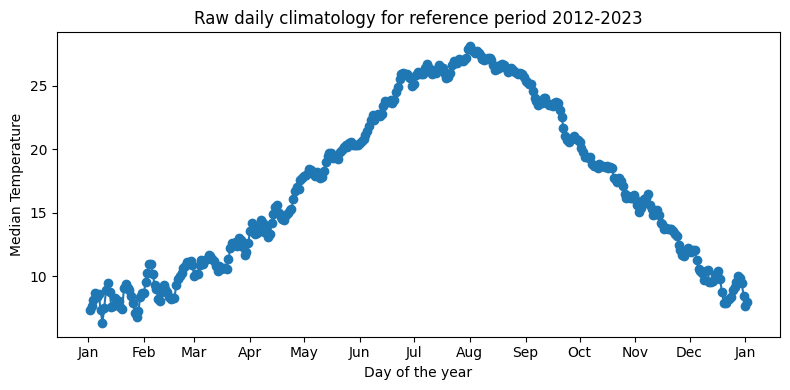

In [ ]:
def plot_clim(clim):
  fix, ax = plt.subplots(figsize=(8,4))
  ax.plot(clim.index, clim.p50, marker='o')
  plt.title("Raw daily climatology for reference period 2012-2023")
  plt.xlabel("Day of the year")
  ax.set_xlim(datetime(2012, 1, 1), datetime(2012, 12, 31))
  ax.xaxis.set_major_locator(mdates.MonthLocator())
  ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
  #plt.xticks(ticks = np.array(list(month_set.keys())), labels = list(month_set.values()), rotation='vertical')
  plt.ylabel("Median Temperature")
  plt.tight_layout()
  plt.show()

plot_clim(create_clim(national_mean_temperature_2012_2023))


Looks normal (bell shaped)

## Step 4: Smoothing

 model selection: pick a family of smoothers of increasing flexibility, and use cross-validation to find the member of that family that predicts unseen data best

In [ ]:
from sklearn.model_selection import KFold

In [ ]:
n_splits=3
K=10
period = 366
cv=KFold(n_splits=n_splits)
years=national_mean_temperature_2012_2023.year.unique()

print(f"each holdout fold contains {len(years)//n_splits} years out of the {len(years)}")
years

each holdout fold contains 4 years out of the 12


array([2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022,
       2023], dtype=int32)

#### Evaluate the fit using RMSE as the Loss Function

In [ ]:
def rmsq(true: pd.Series, predictions: np.ndarray):
  #vectorized
  return np.sqrt(np.mean((predictions - true.values)**2, axis = 1) )

#### First test on some of the stations

In [ ]:
stations_picks = ['thessaloniki', 'pirgos', 'athens', 'xanthi', 'nevrokopi', 'larissa','lefkada', 'heraclion', 'grevena', 'polygyros']
stations_picks

['thessaloniki',
 'pirgos',
 'athens',
 'xanthi',
 'nevrokopi',
 'larissa',
 'lefkada',
 'heraclion',
 'grevena',
 'polygyros']

In [ ]:
from typing import Literal

In [ ]:
def get_cv_results(df, cv_function:Literal['harmonic', 'loess'], K = K, period = period, grid = None)-> tuple[np.ndarray, np.float32, int | None, np.float32 | None, int | None]:

  best_k = None,
  best_frac = None,
  best_it = None
  errors = []

  if cv_function == 'harmonic':
    predictions = harmonic_cross_val(df, K)
    errors = rmsq(df.t_mean, predictions)
  elif cv_function == 'loess':
    predictions = loess_cross_val(df, period, grid)
    true_values = create_clim(df, years)
    errors = rmsq(true_values.p50, predictions)
  else:
   raise ValueError("cv_function must be 'harmonic' or 'loess'")

  best_param_indx = get_best_param_index(errors)

  if cv_function == 'harmonic':
    best_k = best_param_indx+1
  else:
    best_frac,best_it=grid[best_param_indx]
    best_it = int(best_it)

  lowest_error=errors[best_param_indx]

  return errors, lowest_error, best_k, best_frac, best_it

In [ ]:
stations_results = pd.DataFrame(data = stations_picks, columns = ['station'])
stations_results

,station
0,thessaloniki
1,pirgos
2,athens
3,xanthi
4,nevrokopi
5,larissa
6,lefkada
7,heraclion
8,grevena
9,polygyros


### Harmonic Regression

first choose 1 station to test: Athens

In [ ]:
athens= get_station_data(national_mean_temperature_2012_2023,'athens',True)
athens

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,athens,9.4,1,January
1,2012-01-02,2012,athens,8.4,2,January
2,2012-01-03,2012,athens,8.7,3,January
3,2012-01-04,2012,athens,10.2,4,January
4,2012-01-05,2012,athens,10.5,5,January
...,...,...,...,...,...,...
4342,2023-12-27,2023,athens,13.5,361,December
4343,2023-12-28,2023,athens,12.8,362,December
4344,2023-12-29,2023,athens,12.4,363,December
4345,2023-12-30,2023,athens,12.3,364,December


To pick K we fit on the daily data directly (not an already-aggregated climatology), using 5-fold cross-validation split **by year**, so a given year's 365/366 days stay together, fully in training or fully in test

In [ ]:
def make_harmonic(yd:pd.Series, k_order: int, period = period) -> pd.DataFrame:
  """ transform the yd dataFrame series of a year into a harmonic series
  Keyword arguments:
  yd -- the series of days in a year (pd.Series)
  k_order -- the harmonic order (e.g., 1 for 1st harmonic, 2 for 2nd)
  period -- the period of the cycle (default 366 for days in a year)
  the resulting dataframe contains cos and sin as features
  """
  dfs = []
  for k in range(1, k_order + 1):
    # vectorized for cos
    cos = np.cos(2 * np.pi * k * yd / period)
    sin = np.sin(2 * np.pi * k * yd / period)
    # Ensure the DataFrame is created with the correct index from yd
    dfs.append(pd.DataFrame({f"cos{k}": cos, f"sin{k}": sin}, index=yd.index))
  return pd.concat(dfs, axis = 1, ignore_index = False)

In [ ]:
list(cv.split(years))

[(array([ 4,  5,  6,  7,  8,  9, 10, 11]), array([0, 1, 2, 3])),
 (array([ 0,  1,  2,  3,  8,  9, 10, 11]), array([4, 5, 6, 7])),
 (array([0, 1, 2, 3, 4, 5, 6, 7]), array([ 8,  9, 10, 11]))]

 For each of the 3 folds, hold out that fold’s years, fit the harmonic model on the rest, predict the held-out days, and record the RMSE

In [ ]:
make_harmonic(athens.yd, K)

,cos1,sin1,cos2,sin2,cos3,sin3,cos4,sin4,cos5,sin5,cos6,sin6,cos7,sin7,cos8,sin8,cos9,sin9,cos10,sin10
0,0.999853,0.017166,0.999411,0.034328,0.998674,0.051479,0.997643,0.068615,0.996318,0.085731,0.994700,0.102821,0.992788,0.119881,0.990584,0.136906,0.988088,0.153891,0.985301,0.170830
1,0.999411,0.034328,0.997643,0.068615,0.994700,0.102821,0.990584,0.136906,0.985301,0.170830,0.978856,0.204552,0.971257,0.238033,0.962513,0.271234,0.952635,0.304115,0.941634,0.336637
2,0.998674,0.051479,0.994700,0.102821,0.988088,0.153891,0.978856,0.204552,0.967028,0.254671,0.952635,0.304115,0.935717,0.352752,0.916317,0.400454,0.894487,0.447094,0.870285,0.492548
3,0.997643,0.068615,0.990584,0.136906,0.978856,0.204552,0.962513,0.271234,0.941634,0.336637,0.916317,0.400454,0.886680,0.462383,0.852864,0.522133,0.815028,0.579421,0.773351,0.633978
4,0.996318,0.085731,0.985301,0.170830,0.967028,0.254671,0.941634,0.336637,0.909308,0.416125,0.870285,0.492548,0.824855,0.565345,0.773351,0.633978,0.716152,0.697944,0.653680,0.756771
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4342,0.996318,-0.085731,0.985301,-0.170830,0.967028,-0.254671,0.941634,-0.336637,0.909308,-0.416125,0.870285,-0.492548,0.824855,-0.565345,0.773351,-0.633978,0.716152,-0.697944,0.653680,-0.756771
4343,0.997643,-0.068615,0.990584,-0.136906,0.978856,-0.204552,0.962513,-0.271234,0.941634,-0.336637,0.916317,-0.400454,0.886680,-0.462383,0.852864,-0.522133,0.815028,-0.579421,0.773351,-0.633978
4344,0.998674,-0.051479,0.994700,-0.102821,0.988088,-0.153891,0.978856,-0.204552,0.967028,-0.254671,0.952635,-0.304115,0.935717,-0.352752,0.916317,-0.400454,0.894487,-0.447094,0.870285,-0.492548
4345,0.999411,-0.034328,0.997643,-0.068615,0.994700,-0.102821,0.990584,-0.136906,0.985301,-0.170830,0.978856,-0.204552,0.971257,-0.238033,0.962513,-0.271234,0.952635,-0.304115,0.941634,-0.336637


#### Parameter Tuning using K-Fold Cross Validation


Do the whole CV loop for each candidate K

In [ ]:
import statsmodels.api as sm

This implementation uses Pooled OOF to compute the error on the predicted values from all the folds instead of computing the error on the predictions of each fold and then taking the mean of the fold errors.

In [ ]:
def harmonic_cross_val(df, K):
  k_predictions = []
  for k in range(1, K + 1):
    predictions = np.zeros(df.shape[0])

    for i, (train_index, test_index) in enumerate(cv.split(years)):
      train = df[df.year.isin(years[train_index])]
      test = df[df.year.isin(years[test_index])]

      # Build cumulative harmonics: 1, 2, ..., k
      X_train= pd.DataFrame(np.ones(train.shape[0]), index=train.index, columns=['const'])
      X_test = pd.DataFrame(np.ones(test.shape[0]), index=test.index, columns=['const'])

      X_train = X_train.join(make_harmonic(train.yd, k))
      X_test = X_test.join(make_harmonic(test.yd, k))

      y_train = train.t_mean

      model = sm.OLS(y_train, X_train)
      results = model.fit()

      fold_predictions = results.predict(X_test)
      predictions[test.index] = fold_predictions

    k_predictions.append(predictions)
    print(f"Finished CV for K = {k}")

  return np.array(k_predictions)

In [ ]:
k_predictions = harmonic_cross_val(athens, K)

Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10


In [ ]:
k_predictions.shape

(10, 4347)

In [ ]:
# errors_per_k = rmsq(athens.t_mean, k_predictions)
# print(errors_per_k)
# best_k=get_best_param_index(errors_per_k)+1
# print(f"lowest error {errors_per_k[np.argmin(errors_per_k)]}")
# print(f"best K is {best_k}")
errors_per_k, lowest_error, best_k, *rest = get_cv_results(athens, 'harmonic')
print(f"lowest error {lowest_error}")
print(f"best K is {best_k}")

Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10
lowest error 2.552427776219658
best K is 4


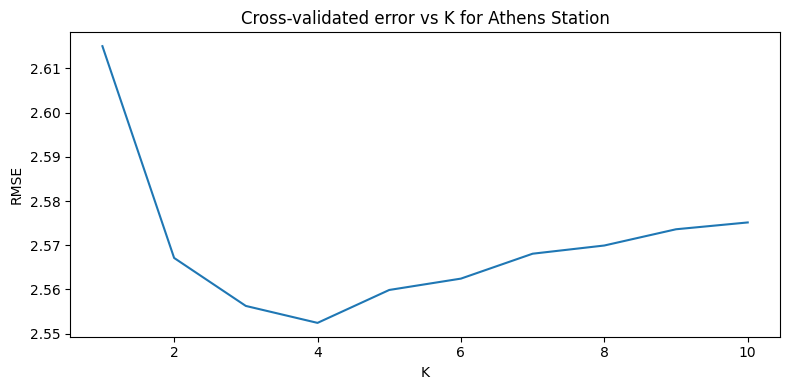

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(list(range(1, len(errors_per_k)+1)), errors_per_k)
plt.title("Cross-validated error vs K for Athens Station")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

#### Now compare best Ks for all station picks

In [ ]:
stations_results.loc[:,'best_k'] = np.nan
stations_results['best_k'] = np.nan
stations_results.loc[:,'harmonic_lowest_error'] = np.nan

In [ ]:
for station in stations_picks:
  print(f"processing station {station}")
  station_data = get_station_data(national_mean_temperature_2012_2023, station, True)
  errors_per_k, lowest_error, best_K, *rest = get_cv_results(station_data, 'harmonic', K)
  row_to_update = stations_results[stations_results['station'] == station]
  stations_results.loc[row_to_update.index, 'best_k'] = best_k
  stations_results.loc[row_to_update.index, 'harmonic_lowest_error'] = lowest_error
stations_results.best_k = stations_results.best_k.astype(int)

processing station thessaloniki
Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10
processing station pirgos
Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10
processing station athens
Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10
processing station xanthi
Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10
proces

For all stations the best K is 4. The errors are range from low 2s to mid 3s

In [ ]:
stations_results

,station,best_k,harmonic_lowest_error
0,thessaloniki,4,2.526731
1,pirgos,4,2.175673
2,athens,4,2.552428
3,xanthi,4,2.862574
4,nevrokopi,4,3.199190
5,larissa,4,2.767750
6,lefkada,4,2.146218
7,heraclion,4,2.355740
8,grevena,4,2.899736
9,polygyros,4,3.379998


#### Use the national data set

In [ ]:
national_errors_per_k, national_lowest_k_error, best_k, *rest = get_cv_results(national_mean_temperature_2012_2023, 'harmonic')
row_to_update = pd.DataFrame(data = ['national'], columns = ['station'])
row_to_update.loc[:, 'best_k'] = best_k
row_to_update.loc[:, 'harmonic_lowest_error'] = lowest_error
stations_results = pd.concat([stations_results, row_to_update], ignore_index=True, axis = 0)

Finished CV for K = 1
Finished CV for K = 2
Finished CV for K = 3
Finished CV for K = 4
Finished CV for K = 5
Finished CV for K = 6
Finished CV for K = 7
Finished CV for K = 8
Finished CV for K = 9
Finished CV for K = 10


In [ ]:
stations_results

,station,best_k,harmonic_lowest_error
0,thessaloniki,4,2.526731
1,pirgos,4,2.175673
2,athens,4,2.552428
3,xanthi,4,2.862574
4,nevrokopi,4,3.199190
5,larissa,4,2.767750
6,lefkada,4,2.146218
7,heraclion,4,2.355740
8,grevena,4,2.899736
9,polygyros,4,3.379998


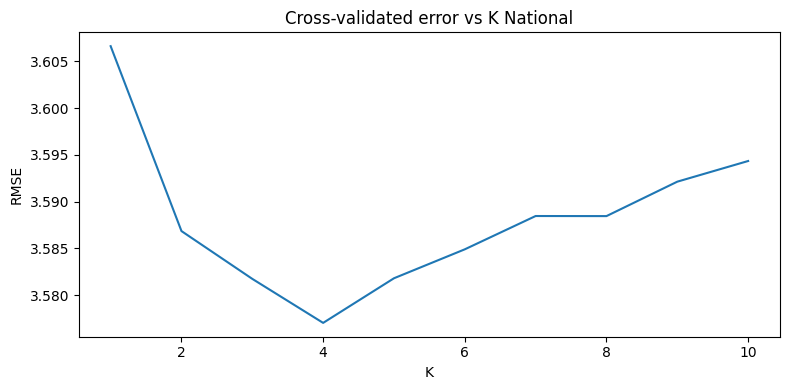

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(list(range(1, len(national_errors_per_k)+1)), national_errors_per_k)
plt.title("Cross-validated error vs K National")
plt.xlabel("K")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

In [ ]:
stations_results[stations_results.station=="national"].best_k.item()

4

#### Get the smoothed national data

In [ ]:
def harmonic_smooth(df: pd.DataFrame, best_k=best_k)-> pd.DataFrame:
  X_harmonic =  pd.DataFrame(np.ones(df.shape[0]), index=df.index, columns=['const'])
  X_harmonic = X_harmonic.join(make_harmonic(df.yd, best_k))
  model = sm.OLS(df.t_mean, X_harmonic)
  results = model.fit()
  harmonic_fitted = results.predict(X_harmonic)
  df_harmonic_fitted = df.copy()
  df_harmonic_fitted.loc[:, ['t_mean']] = harmonic_fitted.astype(np.float32)
  return df_harmonic_fitted

harmonic_smooth(national_mean_temperature_2012_2023, stations_results[stations_results.station=="national"].best_k.item())

,date,year,station,t_mean,yd,month
0,2012-01-01,2012,aghiosnikolaos,7.840306,1,January
1,2012-01-02,2012,aghiosnikolaos,7.797365,2,January
2,2012-01-03,2012,aghiosnikolaos,7.758958,3,January
3,2012-01-04,2012,aghiosnikolaos,7.725061,4,January
4,2012-01-05,2012,aghiosnikolaos,7.695640,5,January
...,...,...,...,...,...,...
224598,2023-12-27,2023,xanthi,8.193342,361,December
224599,2023-12-28,2023,xanthi,8.123216,362,December
224600,2023-12-29,2023,xanthi,8.057570,363,December
224601,2023-12-30,2023,xanthi,7.996438,364,December


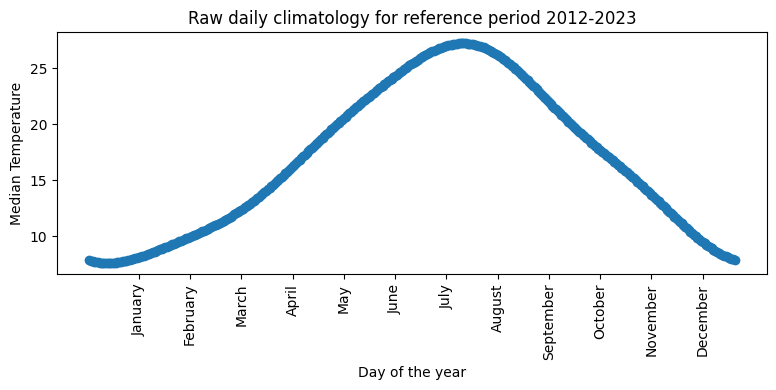

In [ ]:
clim_harmonic = create_clim(harmonic_smooth(national_mean_temperature_2012_2023, stations_results[stations_results.station=="national"].best_k.item()))
plot_clim(clim_harmonic)

#### Compare true data with harmonic smooth data

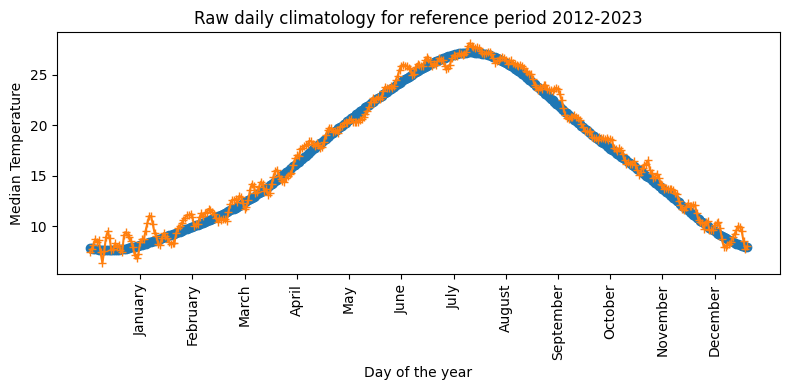

In [ ]:
plt.figure(figsize=(8,4))
plt.plot(clim_harmonic.index, clim_harmonic.p50, marker='o')
plt.plot(national_clim.index, national_clim.p50, marker='+')
plt.title("Raw daily climatology for reference period 2012-2023")
plt.xlabel("Day of the year")
plt.xticks(ticks = np.array(list(month_set.keys())), labels = list(month_set.values()), rotation='vertical')
plt.ylabel("Median Temperature")
plt.tight_layout()
plt.show()

### Local Polynomial Regression Fitting (Loess)

#### Side note: How Lowess works in Statsmodels package

In [ ]:
!curl -L -o loess.dat https://www.itl.nist.gov/div898/handbook/datasets/LOESSCMP.DAT

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  1138    0  1138    0     0   3218      0 --:--:-- --:--:-- --:--:--  3214


In [ ]:
with open('/content/loess.dat', 'r') as f:
  d = f.read()
data = []
cleaned_data = []
for line in d.split('\n')[25:]:
  data.append(line.strip().split(' '))
for pair in data:
  pair = [i for i in pair if i != '']
  if(len(pair)):
    cleaned_data.append([float(i) for i in pair if i != ''])

dt = pd.DataFrame(cleaned_data, columns =['X','y'])
dt

,X,y
0,0.557820,18.63654
1,2.021727,103.49646
2,2.577325,150.35391
3,3.414029,190.51031
4,4.301408,208.70115
5,4.744839,213.71135
6,5.107378,228.49353
7,6.541166,233.55387
8,6.721618,234.55054
9,7.260058,223.89225


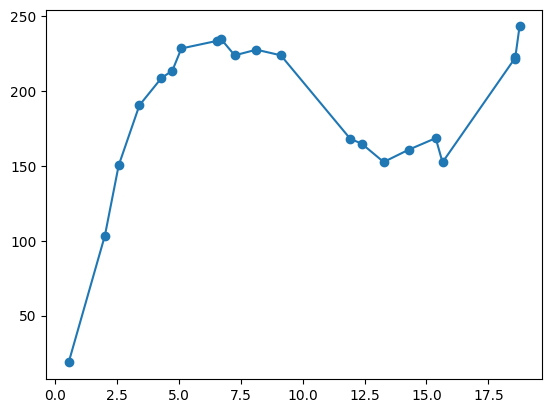

In [ ]:
plt.plot(dt.X, dt.y, marker='o')

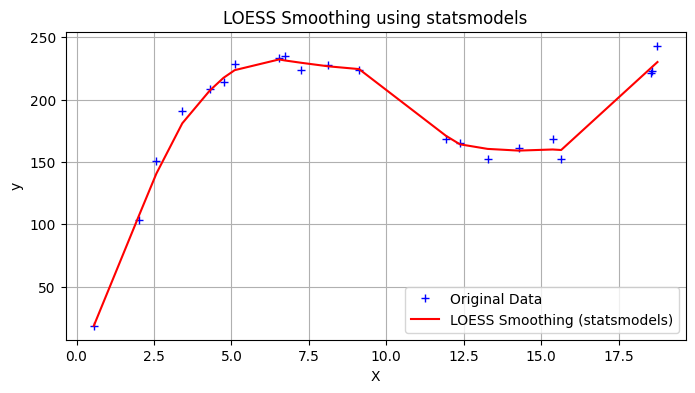

In [ ]:
import statsmodels.api as sm

# Perform LOESS smoothing using statsmodels.api.lowess
# frac parameter controls the smoothness, similar to radius in localreg
# Increase it for smoother curve, decrease for less smooth.
# it corresponds to the fraction of data points used in each local regression
loess_smoothed = sm.nonparametric.lowess(dt.y, dt.X, frac=0.3)

# The result of lowess with default `return_sorted=True` is an array where the first column is X and the second is the smoothed Y
x_smoothed, y_smoothed = loess_smoothed.T

plt.figure(figsize=(8, 4))
plt.plot(dt.X, dt.y, '+', markersize=6, color='blue', label='Original Data')
plt.plot(x_smoothed, y_smoothed, label='LOESS Smoothing (statsmodels)', color='red')
plt.title('LOESS Smoothing using statsmodels')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

#### Compute Lowless for clim

We want to identify general trends for each day of the year over the compressed by day period from 2012 to 2023, so that we can see which values are actual outliers

Loess works on a climatology (one value per day of year), not raw daily data, and it needs help to “see” that day 366 and day 1 are neighbours, the fix used here is to glue three copies of the climatology end to end, smooth that, and keep only the middle copy

In [ ]:
def loess_smooth(yd: pd.Series, y: pd.Series, **params) -> pd.DataFrame:
  period = params.get('period', 366)
  frac = params.get('frac', 0.3)
  it = params.get('it', 1)
  label = params.get('label', 'p50')
  # print(period, frac, it, label)
  X = pd.concat([yd-period, yd, yd+period], ignore_index=True, axis = 0)
  y = pd.concat([y, y, y], ignore_index=True, axis = 0)
  smoothed = sm.nonparametric.lowess(y.values, X.values, frac=frac, it=it, is_sorted=True)
  smoothed_df = pd.DataFrame(smoothed, columns = ['yd', label])
  smoothed_df.yd = smoothed_df.yd.astype(np.int32)
  return smoothed_df[(smoothed_df.yd > 0) & (smoothed_df.yd < 367)].reset_index(drop=True)

#### Example using frac=0.01

In [ ]:
clim_loess = national_clim.reset_index(drop=False)
smoothed_df = loess_smooth(clim_loess.yd, clim_loess.p50, frac=0.01)
smoothed_df

,yd,p50
0,1,7.992120
1,2,8.009312
2,3,8.094556
3,4,8.144575
4,5,8.134098
...,...,...
361,362,9.248629
362,363,9.025317
363,364,8.714673
364,365,8.369707


#### Try multiple frac values

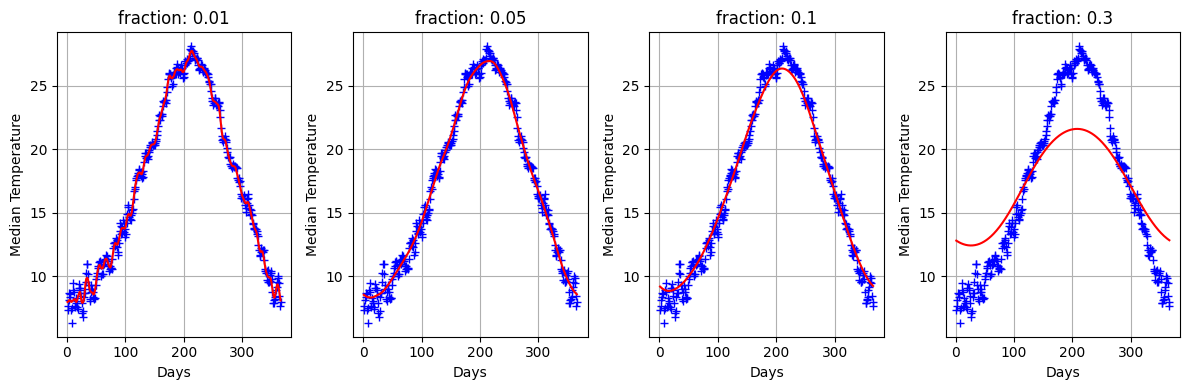

In [ ]:
fraxs = [0.01, 0.05, 0.1, 0.3]
smoothed = map(lambda frac: loess_smooth(clim_loess.yd, clim_loess.p50, frac=frac), fraxs)
fig, ax = plt.subplots(1,len(fraxs), figsize=(12,4))
for i in range(len(fraxs)):
  nxt_i= next(smoothed)
  ax[i].plot(clim_loess.yd, clim_loess.p50, '+', markersize=6, color='blue', label='Original Data')
  ax[i].plot(nxt_i.yd,nxt_i.p50, label='LOESS Smoothing (statsmodels)', color='red')
  ax[i].set_xlabel('Days')
  ax[i].set_ylabel('Median Temperature')
  ax[i].set_title((f"fraction: {fraxs[i]}"))
  ax[i].grid(True)
plt.tight_layout()
plt.show()

In [ ]:
fracs = np.arange(0.05, 0.3, 0.01)
itr = np.arange(1, 6, 1)
grid = np.array(np.meshgrid(fracs, itr)).T.reshape(-1, 2)
grid[0]

array([0.05, 1.  ])

In [ ]:
grid.shape

(125, 2)

Go through the cv loop for each frac,it pair

In [ ]:
def loess_cross_val(df, period=period, grid=grid) -> np.ndarray:
  loess_predictions = []
  for frac, it in grid:
    fold_predictions = np.zeros(period)
    for i, (train_idx, test_idx) in enumerate(cv.split(years)):
      train = create_clim(df, years[train_idx]).reset_index(drop=False)
      test = create_clim(df, years[test_idx]).reset_index(drop=False)
      #fit
      res = loess_smooth(train['yd'], train['p50'], frac=frac, it=int(it))
      x = res.yd.values
      y = res.p50.values
      #predict using linear interpolation (np.interp)
      predict = np.interp(test['yd'], x, y)
      fold_predictions[test.index] = predict

    loess_predictions.append(fold_predictions)
    print(f"Finished CV for frac = {frac}, it = {it}")

  return np.array(loess_predictions)

#### check best loess params for stations picks

In [ ]:
stations_results.loc[:,'best_frac'] = np.nan
stations_results.loc[:,'best_it'] = np.nan
stations_results.loc[:,'loess_lowest_error'] = np.nan

In [ ]:
for station in stations_picks:
  print(f"processing station {station}")
  station_data = get_station_data(national_mean_temperature_2012_2023, station, True)
  errors, lowest_error, _, best_frac, best_it = get_cv_results(station_data, 'loess', grid = grid)
  row_to_update = stations_results[stations_results['station'] == station]
  stations_results.loc[row_to_update.index, 'best_frac'] = best_frac
  stations_results.loc[row_to_update.index, 'best_it'] = best_it
  stations_results.loc[row_to_update.index, 'loess_lowest_error'] = lowest_error


In [ ]:
stations_results

,station,best_k,harmonic_lowest_error,best_frac,best_it,loess_lowest_error
0,thessaloniki,4.0,2.526731,0.05,5.0,0.833000
1,pirgos,4.0,2.175673,0.05,5.0,0.699364
2,athens,4.0,2.552428,0.05,1.0,0.837307
3,xanthi,4.0,2.862574,0.05,5.0,1.018696
4,nevrokopi,4.0,3.199190,0.05,1.0,0.993105
5,larissa,4.0,2.767750,0.05,1.0,0.914506
6,lefkada,4.0,2.146218,0.05,5.0,0.654987
7,heraclion,4.0,2.355740,0.05,1.0,0.710223
8,grevena,4.0,2.899736,0.05,5.0,0.960661
9,polygyros,4.0,3.379998,0.05,2.0,1.215156


In [ ]:
# true_values = create_clim(national_mean_temperature_2012_2023, years)
# errors_loess = rmsq(true_values['p50'], loess_predictions)
# print(errors_loess)
# print(f"lowest error {errors_loess[np.argmin(errors_loess)]}")
# print(f"best params is {grid[np.argmin(errors_loess)]}")
national_loess_errors, lowest_loess_error, _, best_frac, best_it = get_cv_results(national_mean_temperature_2012_2023, 'loess', grid = grid)
row_to_update = stations_results[stations_results['station'] == 'national']
stations_results.loc[row_to_update.index, 'best_frac'] = best_frac
stations_results.loc[row_to_update.index, 'best_it'] = best_it
stations_results.loc[row_to_update.index, 'loess_lowest_error'] = lowest_loess_error

Finished CV for frac = 0.05, it = 1.0
Finished CV for frac = 0.05, it = 2.0
Finished CV for frac = 0.05, it = 3.0
Finished CV for frac = 0.05, it = 4.0
Finished CV for frac = 0.05, it = 5.0
Finished CV for frac = 0.060000000000000005, it = 1.0
Finished CV for frac = 0.060000000000000005, it = 2.0
Finished CV for frac = 0.060000000000000005, it = 3.0
Finished CV for frac = 0.060000000000000005, it = 4.0
Finished CV for frac = 0.060000000000000005, it = 5.0
Finished CV for frac = 0.07, it = 1.0
Finished CV for frac = 0.07, it = 2.0
Finished CV for frac = 0.07, it = 3.0
Finished CV for frac = 0.07, it = 4.0
Finished CV for frac = 0.07, it = 5.0
Finished CV for frac = 0.08000000000000002, it = 1.0
Finished CV for frac = 0.08000000000000002, it = 2.0
Finished CV for frac = 0.08000000000000002, it = 3.0
Finished CV for frac = 0.08000000000000002, it = 4.0
Finished CV for frac = 0.08000000000000002, it = 5.0
Finished CV for frac = 0.09000000000000001, it = 1.0
Finished CV for frac = 0.0900000

In [ ]:
stations_results

,station,best_k,harmonic_lowest_error,best_frac,best_it,loess_lowest_error
0,thessaloniki,4,2.526731,NaN,NaN,NaN
1,pirgos,4,2.175673,NaN,NaN,NaN
2,athens,4,2.552428,NaN,NaN,NaN
3,xanthi,4,2.862574,NaN,NaN,NaN
4,nevrokopi,4,3.199190,NaN,NaN,NaN
5,larissa,4,2.767750,NaN,NaN,NaN
6,lefkada,4,2.146218,NaN,NaN,NaN
7,heraclion,4,2.355740,NaN,NaN,NaN
8,grevena,4,2.899736,NaN,NaN,NaN
9,polygyros,4,3.379998,NaN,NaN,NaN


In [ ]:
stations_results.to_csv('/content/stations_results.csv')

In [ ]:
national_loess_errors

array([0.66586904, 0.6651826 , 0.6649592 , 0.66491199, 0.66490255,
       0.67981776, 0.68060302, 0.68096286, 0.68121089, 0.68133344,
       0.70501314, 0.70751245, 0.70806726, 0.70826383, 0.70833123,
       0.73464782, 0.73874433, 0.74004267, 0.74043065, 0.74060643,
       0.781903  , 0.78886572, 0.79098418, 0.7915668 , 0.79174449,
       0.83064784, 0.84061671, 0.84302659, 0.84337263, 0.84348075,
       0.90054391, 0.91085245, 0.91402399, 0.91463231, 0.9148654 ,
       0.96623707, 0.98081295, 0.98187856, 0.982586  , 0.98278959,
       1.06062534, 1.07693388, 1.08142968, 1.08263078, 1.08289491,
       1.15008065, 1.16561883, 1.17033943, 1.17145623, 1.17181332,
       1.25911409, 1.27517474, 1.2782339 , 1.27894319, 1.2791064 ,
       1.3649058 , 1.3757726 , 1.3798764 , 1.3810967 , 1.38145582,
       1.49508775, 1.50815145, 1.51181327, 1.51273215, 1.51296526,
       1.60448322, 1.62540766, 1.62932331, 1.63043192, 1.63071134,
       1.74672663, 1.77110598, 1.77864854, 1.78082542, 1.78145

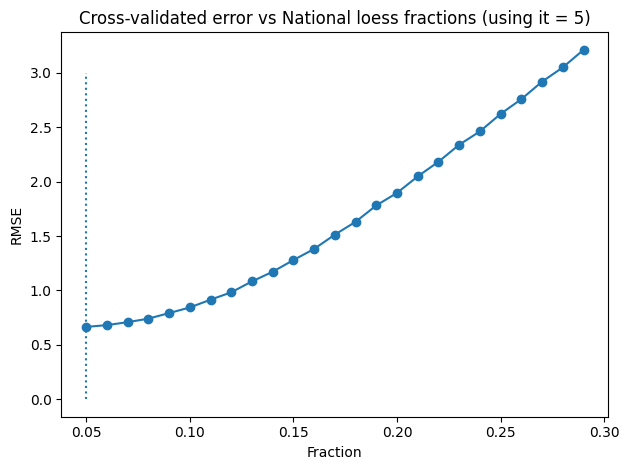

In [ ]:
plt.plot(fracs,[a[int(best_it)-1] for a in national_loess_errors.reshape((25,5))], marker='o')
plt.title("Cross-validated error vs National loess fractions (using it = 5)")
plt.vlines([best_frac], 0 , 3.0, linestyles=['dotted'])
plt.xlabel("Fraction")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

the fraction of data points used in each local regression is:

In [ ]:
period*best_frac

np.float64(18.3)

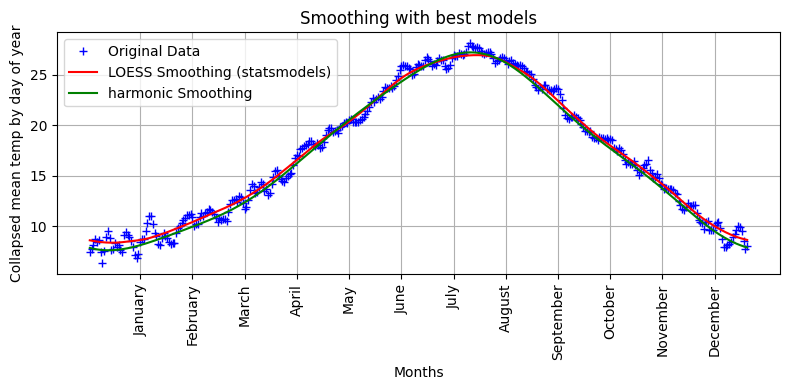

In [ ]:
best_smoothed_loess = loess_smooth(clim_loess.yd, clim_loess.p50, frac=best_frac, it=int(best_it))
# for the harmonic data we need to covert it to clim shape
best_smoothed_harmonic = create_clim(harmonic_smooth(national_mean_temperature_2012_2023, best_k))
plt.figure(figsize=(8, 4))
plt.plot(clim_loess.yd, clim_loess.p50, '+', markersize=6, color='blue', label='Original Data')
plt.plot(best_smoothed_loess.yd, best_smoothed_loess.p50, label='LOESS Smoothing (statsmodels)', color='red')
plt.plot(best_smoothed_harmonic.index, best_smoothed_harmonic.p50, color='green', label='harmonic Smoothing')
plt.title('Smoothing with best models')
plt.xlabel('Months')
plt.xticks(ticks = np.array(list(month_set.keys())), labels = list(month_set.values()), rotation='vertical')
plt.ylabel('Collapsed mean temp by day of year')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

##  The new chart

since the loess method has the smallest errors on the national scale, we will use this over the harmonic method

#### Create Smoothed data for central measure and range

In [ ]:
p5_smoothed=loess_smooth(clim_loess.yd, clim_loess.p5, frac=best_frac, it=int(best_it), label = 'p5')
p50_smoothed=loess_smooth(clim_loess.yd, clim_loess.p50, frac=best_frac, it=int(best_it))
p95_smoothed=loess_smooth(clim_loess.yd, clim_loess.p95, frac=best_frac, it=int(best_it), label = 'p95')
normal = p50_smoothed.merge(p5_smoothed, on='yd').merge(p95_smoothed, on='yd')
normal

,yd,p50,p5,p95
0,1,8.596029,0.067705,15.106675
1,2,8.560301,0.018185,15.087455
2,3,8.527313,-0.028926,15.069906
3,4,8.497092,-0.073470,15.054044
4,5,8.469679,-0.115310,15.039744
...,...,...,...,...
361,362,8.824093,0.367549,15.232281
362,363,8.771005,0.298461,15.202149
363,364,8.721879,0.234529,15.174959
364,365,8.676525,0.175220,15.150222


#### Note: there is no February 29 in year 2025, so we have to fill the missing value when we merge the normal and the 2025 tables

In [ ]:
national_mean_temperature_2012_2023[(national_mean_temperature_2012_2023.month == 'February') & (national_mean_temperature_2012_2023.yd == 60) ]

,date,year,station,t_mean,yd,month
59,2012-02-29,2012,aghiosnikolaos,7.800000,60,February
1520,2016-02-29,2016,aghiosnikolaos,17.200001,60,February
2979,2020-02-29,2020,aghiosnikolaos,13.400000,60,February
4440,2012-02-29,2012,alexandroupolis,-1.100000,60,February
5901,2016-02-29,2016,alexandroupolis,10.300000,60,February
...,...,...,...,...,...,...
217387,2016-02-29,2016,volos,17.700001,60,February
218846,2020-02-29,2020,volos,10.500000,60,February
220307,2012-02-29,2012,xanthi,0.600000,60,February
221761,2016-02-29,2016,xanthi,12.900000,60,February


In [ ]:
national_mean_temperature_2012_2023[national_mean_temperature_2012_2023["month"].isin(["February", "March"])].groupby(["year","month"]).yd.max()

year  month   
2012  February    60
      March       91
2013  February    59
      March       90
2014  February    59
      March       90
2015  February    59
      March       90
2016  February    60
      March       91
2017  February    59
      March       90
2018  February    59
      March       90
2019  February    59
      March       90
2020  February    60
      March       91
2021  February    59
      March       90
2022  February    59
      March       90
2023  February    59
      March       90
Name: yd, dtype: int32

In [ ]:
open_meteo_daily_df.shape

(18980, 8)

In [ ]:
open_meteo_daily_data = open_meteo_daily_df[national_mean_temperature_2012_2023.columns]
open_meteo_daily_data

,date,year,station,t_mean,yd,month
0,2025-01-01 00:00:00+00:00,2025,aghiosnikolaos,12.602000,1,January
1,2025-01-02 00:00:00+00:00,2025,aghiosnikolaos,12.260331,2,January
2,2025-01-03 00:00:00+00:00,2025,aghiosnikolaos,14.433249,3,January
3,2025-01-04 00:00:00+00:00,2025,aghiosnikolaos,14.649917,4,January
4,2025-01-05 00:00:00+00:00,2025,aghiosnikolaos,13.702003,5,January
...,...,...,...,...,...,...
18610,2025-12-27 00:00:00+00:00,2025,xanthi,3.756250,361,December
18611,2025-12-28 00:00:00+00:00,2025,xanthi,3.475000,362,December
18612,2025-12-29 00:00:00+00:00,2025,xanthi,2.075000,363,December
18613,2025-12-30 00:00:00+00:00,2025,xanthi,4.064583,364,December


In [ ]:
february_29_data = national_mean_temperature_2012_2023[(national_mean_temperature_2012_2023.month == 'February') & (national_mean_temperature_2012_2023.yd == 60)]
february_29_data

,date,year,station,t_mean,yd,month
59,2012-02-29,2012,aghiosnikolaos,7.800000,60,February
1520,2016-02-29,2016,aghiosnikolaos,17.200001,60,February
2979,2020-02-29,2020,aghiosnikolaos,13.400000,60,February
4440,2012-02-29,2012,alexandroupolis,-1.100000,60,February
5901,2016-02-29,2016,alexandroupolis,10.300000,60,February
...,...,...,...,...,...,...
217387,2016-02-29,2016,volos,17.700001,60,February
218846,2020-02-29,2020,volos,10.500000,60,February
220307,2012-02-29,2012,xanthi,0.600000,60,February
221761,2016-02-29,2016,xanthi,12.900000,60,February


year 2025 didn't have a February 29 day

In [ ]:
open_meteo_daily_data.loc[(open_meteo_daily_df.month == 'February') & (open_meteo_daily_data.yd == 60)]

,date,year,station,t_mean,yd,month


In [ ]:
open_meteo_daily_data.yd.unique().shape, normal.yd.unique().shape

((365,), (366,))

 #### join the smoothed data onto the 2025 daily data and compute the anomaly

collapse the 2025 data to a national daily series

In [ ]:
collapsed_2025 = open_meteo_daily_data.groupby("date").agg({"t_mean": "median"}).reset_index(drop=False)
collapsed_2025.rename(columns={"t_mean":"tmed"}, inplace=True)
collapsed_2025.loc[:,"month"] = collapsed_2025.date.dt.month_name()
collapsed_2025.loc[:,"year"] = collapsed_2025.date.dt.year
collapsed_2025.loc[:,"yd"] = collapsed_2025.date.dt.day_of_year
collapsed_2025

,date,tmed,month,year,yd
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5
...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,7.947959,December,2025,361
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364


In [ ]:
collapsed_2025

,date,tmed,month,year,yd
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5
...,...,...,...,...,...
360,2025-12-27 00:00:00+00:00,7.947959,December,2025,361
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364


keep the February 29 rows from the right (normal) table when we merge. This will create 1 Null value for day 60 (February 29) in the merge climatologic

In [ ]:
comp = collapsed_2025.merge(normal, on='yd', how='right', suffixes=('_normal', '_2025'))
comp

,date,tmed,month,year,yd,p50,p5,p95
0,2025-01-01 00:00:00+00:00,7.956250,January,2025.0,1,8.596029,0.067705,15.106675
1,2025-01-02 00:00:00+00:00,8.083209,January,2025.0,2,8.560301,0.018185,15.087455
2,2025-01-03 00:00:00+00:00,9.871542,January,2025.0,3,8.527313,-0.028926,15.069906
3,2025-01-04 00:00:00+00:00,10.964166,January,2025.0,4,8.497092,-0.073470,15.054044
4,2025-01-05 00:00:00+00:00,9.206125,January,2025.0,5,8.469679,-0.115310,15.039744
...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,7.960000,December,2025.0,362,8.824093,0.367549,15.232281
362,2025-12-29 00:00:00+00:00,7.046875,December,2025.0,363,8.771005,0.298461,15.202149
363,2025-12-30 00:00:00+00:00,8.945459,December,2025.0,364,8.721879,0.234529,15.174959
364,2025-12-31 00:00:00+00:00,5.089917,December,2025.0,365,8.676525,0.175220,15.150222


we can see the missing values for the 2025 data

In [ ]:
comp.isna().sum()

,0
date,1
tmed,1
month,1
year,1
yd,0
p50,0
p5,0
p95,0


In [ ]:
comp.ffill(inplace=True, limit=1)
comp.isna().sum()

,0
date,0
tmed,0
month,0
year,0
yd,0
p50,0
p5,0
p95,0


In [ ]:
comp.year = comp.year.astype(np.int32)
comp

,date,tmed,month,year,yd,p50,p5,p95
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1,8.596029,0.067705,15.106675
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2,8.560301,0.018185,15.087455
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3,8.527313,-0.028926,15.069906
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4,8.497092,-0.073470,15.054044
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5,8.469679,-0.115310,15.039744
...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362,8.824093,0.367549,15.232281
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363,8.771005,0.298461,15.202149
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364,8.721879,0.234529,15.174959
364,2025-12-31 00:00:00+00:00,5.089917,December,2025,365,8.676525,0.175220,15.150222


In [ ]:
comp.loc[:,"anom"] = comp['tmed'] - comp['p50']
comp

,date,tmed,month,year,yd,p50,p5,p95,anom
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1,8.596029,0.067705,15.106675,-0.639780
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2,8.560301,0.018185,15.087455,-0.477092
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3,8.527313,-0.028926,15.069906,1.344229
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4,8.497092,-0.073470,15.054044,2.467073
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5,8.469679,-0.115310,15.039744,0.736447
...,...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362,8.824093,0.367549,15.232281,-0.864093
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363,8.771005,0.298461,15.202149,-1.724130
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364,8.721879,0.234529,15.174959,0.223581
364,2025-12-31 00:00:00+00:00,5.089917,December,2025,365,8.676525,0.175220,15.150222,-3.586608


In [ ]:
comp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype              
---  ------  --------------  -----              
 0   date    366 non-null    datetime64[ns, UTC]
 1   tmed    366 non-null    float32            
 2   month   366 non-null    object             
 3   year    366 non-null    int32              
 4   yd      366 non-null    int32              
 5   p50     366 non-null    float64            
 6   p5      366 non-null    float64            
 7   p95     366 non-null    float64            
 8   anom    366 non-null    float64            
dtypes: datetime64[ns, UTC](1), float32(1), float64(4), int32(2), object(1)
memory usage: 21.6+ KB


create values to annotate the largest positive anomaly per month,  
and the single largest negative anomaly of the year (2025)

In [ ]:
comp.groupby("month")["anom"].transform("max")

,anom
0,4.074529
1,4.074529
2,4.074529
3,4.074529
4,4.074529
...,...
361,1.989671
362,1.989671
363,1.989671
364,1.989671


In [ ]:
comp

,date,tmed,month,year,yd,p50,p5,p95,anom
0,2025-01-01 00:00:00+00:00,7.956250,January,2025,1,8.596029,0.067705,15.106675,-0.639780
1,2025-01-02 00:00:00+00:00,8.083209,January,2025,2,8.560301,0.018185,15.087455,-0.477092
2,2025-01-03 00:00:00+00:00,9.871542,January,2025,3,8.527313,-0.028926,15.069906,1.344229
3,2025-01-04 00:00:00+00:00,10.964166,January,2025,4,8.497092,-0.073470,15.054044,2.467073
4,2025-01-05 00:00:00+00:00,9.206125,January,2025,5,8.469679,-0.115310,15.039744,0.736447
...,...,...,...,...,...,...,...,...,...
361,2025-12-28 00:00:00+00:00,7.960000,December,2025,362,8.824093,0.367549,15.232281,-0.864093
362,2025-12-29 00:00:00+00:00,7.046875,December,2025,363,8.771005,0.298461,15.202149,-1.724130
363,2025-12-30 00:00:00+00:00,8.945459,December,2025,364,8.721879,0.234529,15.174959,0.223581
364,2025-12-31 00:00:00+00:00,5.089917,December,2025,365,8.676525,0.175220,15.150222,-3.586608


In [ ]:
comp.groupby("month")["anom"].max()

,anom
month,
April,2.520209
August,2.246845
December,1.989671
February,2.255929
January,4.074529
July,4.724270
June,4.849327
March,6.059303
May,2.587954


In [ ]:
comp.groupby("month")["anom"].idxmax()

,anom
month,
April,106
August,222
December,337
February,31
January,7
July,205
June,177
March,73
May,143


In [ ]:
comp.loc[comp.groupby("month")["anom"].idxmax().values, :]

,date,tmed,month,year,yd,p50,p5,p95,anom
106,2025-04-17 00:00:00+00:00,17.776749,April,2025,107,15.256540,9.675061,19.634682,2.520209
222,2025-08-11 00:00:00+00:00,29.066250,August,2025,223,26.819405,22.027850,30.234498,2.246845
337,2025-12-04 00:00:00+00:00,13.216541,December,2025,338,11.226870,3.296251,17.132923,1.989671
31,2025-02-01 00:00:00+00:00,10.981874,February,2025,32,8.725946,0.399731,15.070653,2.255929
7,2025-01-08 00:00:00+00:00,12.480333,January,2025,8,8.405804,-0.224492,15.005673,4.074529
205,2025-07-25 00:00:00+00:00,31.530750,July,2025,206,26.806481,22.018772,30.609298,4.724270
177,2025-06-27 00:00:00+00:00,29.961040,June,2025,178,25.111713,19.942538,29.091435,4.849327
73,2025-03-15 00:00:00+00:00,17.695833,March,2025,74,11.636530,4.845078,16.285454,6.059303
143,2025-05-24 00:00:00+00:00,22.813751,May,2025,144,20.225797,15.008236,24.773102,2.587954
324,2025-11-21 00:00:00+00:00,17.418207,November,2025,325,13.243259,5.989956,18.656461,4.174948


In [ ]:
comp.anom.min()

-6.591286825042646

In [ ]:
comp.loc[[comp.anom.idxmin()], :]

,date,tmed,month,year,yd,p50,p5,p95,anom
52,2025-02-22 00:00:00+00:00,3.449292,February,2025,53,10.040579,2.676765,15.389253,-6.591287


In [ ]:
annot = pd.concat([comp.loc[comp.groupby("month")["anom"].idxmax().values, :], comp.loc[[comp.anom.idxmin()], :]], axis = 0)
annot

,date,tmed,month,year,yd,p50,p5,p95,anom
106,2025-04-17 00:00:00+00:00,17.776749,April,2025,107,15.256540,9.675061,19.634682,2.520209
222,2025-08-11 00:00:00+00:00,29.066250,August,2025,223,26.819405,22.027850,30.234498,2.246845
337,2025-12-04 00:00:00+00:00,13.216541,December,2025,338,11.226870,3.296251,17.132923,1.989671
31,2025-02-01 00:00:00+00:00,10.981874,February,2025,32,8.725946,0.399731,15.070653,2.255929
7,2025-01-08 00:00:00+00:00,12.480333,January,2025,8,8.405804,-0.224492,15.005673,4.074529
205,2025-07-25 00:00:00+00:00,31.530750,July,2025,206,26.806481,22.018772,30.609298,4.724270
177,2025-06-27 00:00:00+00:00,29.961040,June,2025,178,25.111713,19.942538,29.091435,4.849327
73,2025-03-15 00:00:00+00:00,17.695833,March,2025,74,11.636530,4.845078,16.285454,6.059303
143,2025-05-24 00:00:00+00:00,22.813751,May,2025,144,20.225797,15.008236,24.773102,2.587954
324,2025-11-21 00:00:00+00:00,17.418207,November,2025,325,13.243259,5.989956,18.656461,4.174948


#### create the canvas

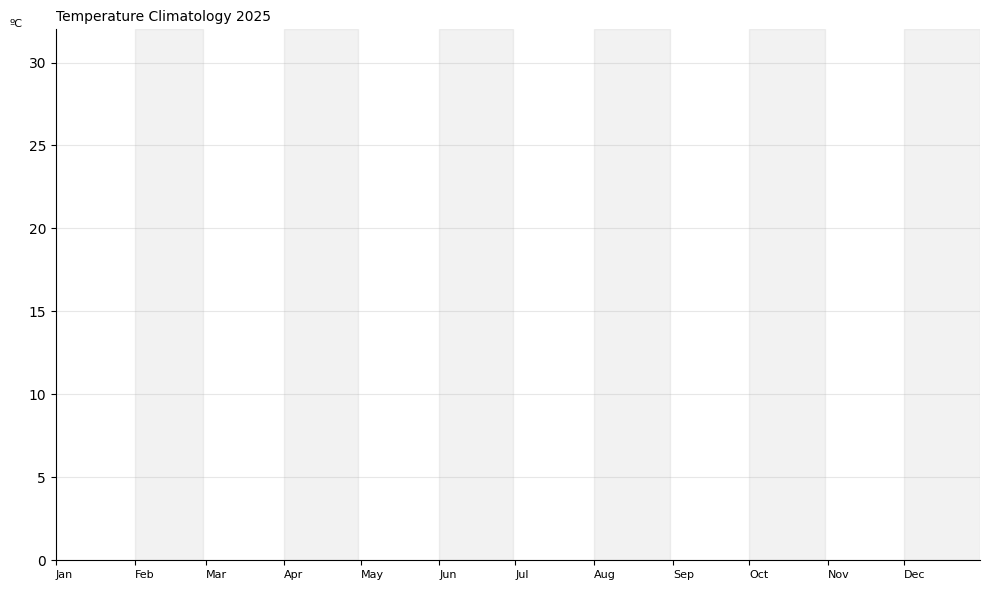

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

# 1. Replicating geom_rect: Alternating grey background for every 2nd month
# Starting from Feb 2025
for month in range(2, 13, 2):
    start = pd.Timestamp(f'2025-{month:02d}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, color='grey', alpha=0.1, zorder=0)

# 2. Replicating scale_y_continuous
ax.set_ylim(3, 32)
ax.set_yticks(range(0, 31, 5))
ax.set_ylabel("ºC", rotation=0, loc='top', fontsize=8)

# 3. Replicating scale_x_date
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))

# 4. Replicating theme adjustments
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle='-', alpha=0.3)

# Adjust tick alignment to match 'hjust = -1.2' logic (centering under the month block)
for tick in ax.get_xticklabels():
    tick.set_horizontalalignment('left')
    tick.set_fontsize(8)

plt.title("Temperature Climatology 2025", loc='left', fontsize=10)
plt.tight_layout()
plt.show()

#### add the data

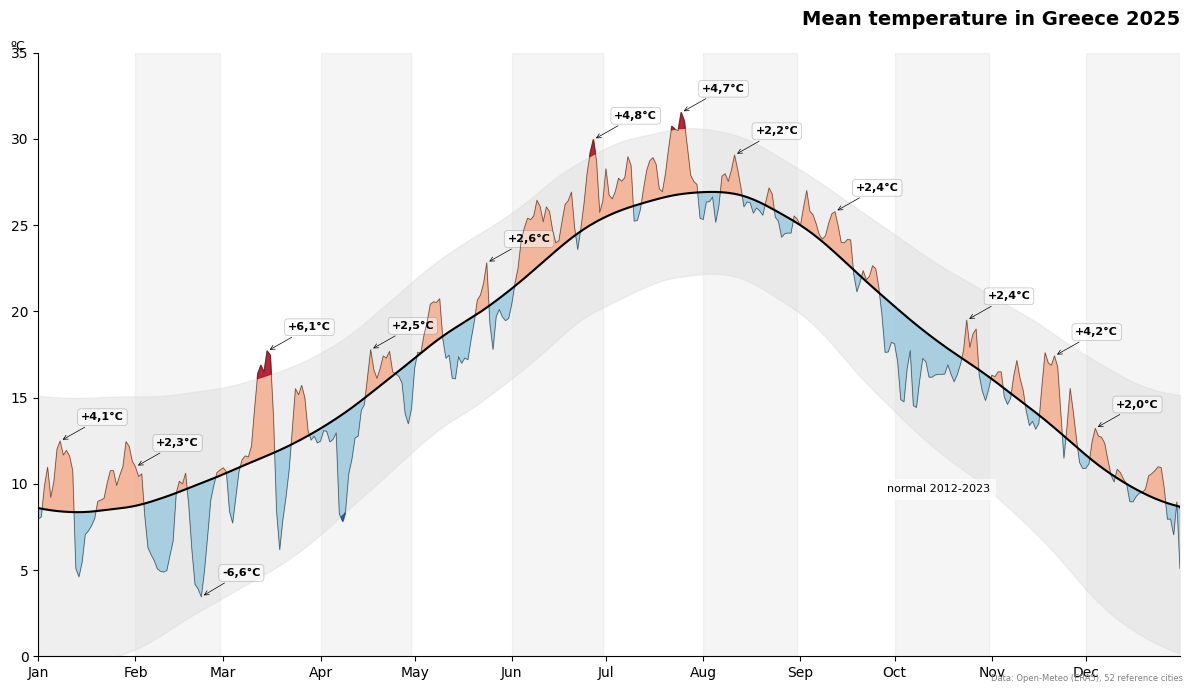

In [ ]:
# Prepare figure and axis
fig, ax = plt.subplots(figsize=(12, 7))

# 1. Background Shading (Alternating Months)
for month in range(2, 13, 2):
    start = pd.Timestamp(f'2025-{month:02d}-01')
    end = start + pd.offsets.MonthEnd(0)
    ax.axvspan(start, end, color='grey', alpha=0.08, zorder=0)

# 2. Historical Range (P5-P95 Ribbon)
ax.fill_between(comp['date'], comp['p5'], comp['p95'], color='#d9d9d9', alpha=0.4, label='Typical Range (P5-P95)', zorder=1)

# # 3. Anomaly Shading (stat_difference logic)
ax.fill_between(comp['date'], comp['p50'], comp['tmed'],
                where=(comp['tmed'] >= comp['p50']),
                color='#f4a582', alpha=0.75, interpolate=True, zorder=2)
ax.fill_between(comp['date'], comp['p50'], comp['tmed'],
                where=(comp['tmed'] < comp['p50']),
                color='#92c5de', alpha=0.75, interpolate=True, zorder=2)

# 4. Extreme Highlights
ax.fill_between(comp['date'], comp['p95'], comp['tmed'],
                where=(comp['tmed'] > comp['p95']),
                color='#b2182b', alpha=0.90, interpolate=True, zorder=3)
ax.fill_between(comp['date'], comp['p5'], comp['tmed'],
                where=(comp['tmed'] < comp['p5']),
                color='#2166ac', alpha=0.90, interpolate=True, zorder=3)

# 5. Lines
## plot all the original data
ax.plot(comp['date'], comp['tmed'], color='#333333', linewidth=0.5, alpha=0.8, zorder=4)
## plot the smooothed data
ax.plot(comp['date'], comp['p50'], color='black', linewidth=1.5, zorder=6, label='Normal (2012-2023)')

# 6. Annotations
for _, row in annot.iterrows():
    ax.annotate(f"{row['anom']:+.1f}°C".replace('.', ','),
                xy=(row['date'], row['tmed']),
                xytext=(15, 15), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.5, ec='grey', lw=0.5),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3', color='black', lw=0.5),
                fontsize=8, fontweight='bold')

# 7. Labels and Text
ax.text(pd.Timestamp("2025-10-15"), 9.5, "normal 2012-2023",
        fontsize=8, ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

# Formatting
ax.set_ylim(0, 35)
ax.set_ylabel("ºC", rotation=0, loc='top', fontsize=9, labelpad=-10)
ax.set_xlim(pd.Timestamp("2025-01-01"), pd.Timestamp("2025-12-31"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Title and Caption
plt.title("Mean temperature in Greece 2025", loc='right', fontsize=14, fontweight='bold', pad=20)
fig.text(0.99, 0.02, "Data: Open-Meteo (ERA5), 52 reference cities", ha='right', fontsize=6, color='grey')

plt.tight_layout()
plt.show()

In [ ]:
pd.DataFrame(data = np.array([[comp.anom.mean(), np.sum(comp.tmed > comp.p95), np.sum(comp.tmed < comp.p5)]]), columns=["mean_anom", 'days above_p95', 'days below_p5'])

,mean_anom,days above_p95,days below_p5
0,0.159229,11.0,1.0
